In [1]:

# First, let's check for any data files that might exist
import os
import glob

# Check for any data files in common formats
data_patterns = ['*.csv', '*.parquet', '*.npy', '*.npz', '*.h5', '*.hdf5']
data_files = []
for pattern in data_patterns:
 data_files.extend(glob.glob(pattern))
 
print("Data files found in current directory:")
for f in sorted(data_files):
 print(f" {f}")
 
# Check for any subdirectories
subdirs = [d for d in os.listdir('.') if os.path.isdir(d) and not d.startswith('.')]
print(f"\nSubdirectories found: {subdirs}")


Data files found in current directory:

Subdirectories found: []


In [2]:

# Based on the dataset description, we need to compute the partial sums for:
# 1. L_DH^(ε=0): a_n = (-1)^ω(n) for squarefree n, 0 otherwise
# 2. Riemann ζ: a_n = 1 for all n
# We'll use N=10^5 as specified

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import zeta
from collections import defaultdict
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
N = 10**5 # Truncation length
t_max = 2000 # Height range for exploration
dt = 2 * np.pi / np.log(N) # Standard sampling resolution

print(f"Parameters:")
print(f" N = {N:,}")
print(f" t_max = {t_max:,}")
print(f" dt = {dt:.4f}")
print(f" Number of t points: {int(t_max / dt)}")


Parameters:
 N = 100,000
 t_max = 2,000
 dt = 0.5458
 Number of t points: 3664


In [3]:

# First, we need to compute the prime factorization and omega function
# Let's use a sieve-based approach for efficiency

def compute_omega_and_squarefree(N):
 """
 Compute ω(n) (number of distinct prime factors) and determine if n is squarefree
 for all n up to N using a sieve.
 
 Returns:
 omega: array where omega[n] = ω(n)
 is_squarefree: array where is_squarefree[n] = True if n is squarefree
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 is_squarefree = np.ones(N + 1, dtype=bool)
 
 # Sieve for omega
 for p in range(2, N + 1):
 if omega[p] == 0: # p is prime
 # Mark all multiples of p
 for n in range(p, N + 1, p):
 omega[n] += 1
 
 # Mark all multiples of p^2 as not squarefree
 if p * p <= N:
 for n in range(p * p, N + 1, p * p):
 is_squarefree[n] = False
 
 return omega, is_squarefree

print("Computing ω(n) and squarefree flags...")
omega, is_squarefree = compute_omega_and_squarefree(N)
print(f"Done. Found {np.sum(is_squarefree[1:])} squarefree numbers up to {N:,}")


Computing ω(n) and squarefree flags...


Done. Found 60794 squarefree numbers up to 100,000


In [4]:

# Define the coefficient functions
def get_coefficients_zeta(N):
 """Riemann zeta: a_n = 1 for all n"""
 a = np.ones(N + 1, dtype=np.float64)
 a[0] = 0 # No n=0 term
 return a

def get_coefficients_L_DH_eps0(N, omega, is_squarefree):
 """L_DH^(ε=0): a_n = (-1)^ω(n) for squarefree n, 0 otherwise"""
 a = np.zeros(N + 1, dtype=np.float64)
 a[is_squarefree] = (-1.0) ** omega[is_squarefree]
 a[0] = 0 # No n=0 term
 return a

# Generate coefficients
a_zeta = get_coefficients_zeta(N)
a_L_DH = get_coefficients_L_DH_eps0(N, omega, is_squarefree)

print("Coefficient statistics:")
print(f" ζ: a_n = 1 for all n (sum = {np.sum(a_zeta):.0f})")
print(f" L_DH^(ε=0):")
print(f" Non-zero coefficients: {np.sum(a_L_DH != 0)}")
print(f" a_n = +1: {np.sum(a_L_DH == 1)}")
print(f" a_n = -1: {np.sum(a_L_DH == -1)}")
print(f" Sum: {np.sum(a_L_DH):.0f}")


Coefficient statistics:
 ζ: a_n = 1 for all n (sum = 100000)
 L_DH^(ε=0):
 Non-zero coefficients: 60794
 a_n = +1: 30373
 a_n = -1: 30421
 Sum: -48


In [5]:

# Implement Kahan compensated summation for numerical precision
def kahan_sum_complex(values):
 """Kahan compensated summation for complex arrays"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j # Running compensation
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

def compute_partial_sum(a, t, N):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n n^(-1/2-it)
 Using Kahan summation for numerical precision
 """
 n = np.arange(1, N + 1)
 # Compute n^(-1/2 - it) = n^(-1/2) * exp(-it * log(n))
 log_n = np.log(n)
 n_power = n ** (-0.5) * np.exp(-1j * t * log_n)
 
 # Multiply by coefficients
 terms = a[1:] * n_power
 
 # Use Kahan summation
 return kahan_sum_complex(terms)

# Test with a single value
t_test = 100.0
D_zeta = compute_partial_sum(a_zeta, t_test, N)
D_L_DH = compute_partial_sum(a_L_DH, t_test, N)

print(f"Test at t = {t_test}:")
print(f" D_ζ(t) = {D_zeta.real:.6f} + {D_zeta.imag:.6f}i, |D| = {abs(D_zeta):.6f}")
print(f" D_L_DH(t) = {D_L_DH.real:.6f} + {D_L_DH.imag:.6f}i, |D| = {abs(D_L_DH):.6f}")


Test at t = 100.0:
 D_ζ(t) = 5.840408 + 0.281657i, |D| = 5.847196
 D_L_DH(t) = 0.246557 + 0.256805i, |D| = 0.356004


In [6]:

# Now compute the time series for both functions to find peaks
# We'll compute over a range of t values

t_values = np.arange(0, t_max, dt)
print(f"Computing time series for {len(t_values)} values of t...")

D_zeta_series = np.zeros(len(t_values), dtype=np.complex128)
D_L_DH_series = np.zeros(len(t_values), dtype=np.complex128)

# Precompute n^(-1/2) and log(n) for efficiency
n = np.arange(1, N + 1)
n_sqrt_inv = n ** (-0.5)
log_n = np.log(n)
a_zeta_vec = a_zeta[1:]
a_L_DH_vec = a_L_DH[1:]

for i, t in enumerate(t_values):
 if i % 500 == 0:
 print(f" Progress: {i}/{len(t_values)} ({100*i/len(t_values):.1f}%)")
 
 # Compute n^(-1/2 - it)
 n_power = n_sqrt_inv * np.exp(-1j * t * log_n)
 
 # For zeta
 terms_zeta = a_zeta_vec * n_power
 D_zeta_series[i] = kahan_sum_complex(terms_zeta)
 
 # For L_DH
 terms_L_DH = a_L_DH_vec * n_power
 D_L_DH_series[i] = kahan_sum_complex(terms_L_DH)

print("Done.")

# Compute magnitudes
mag_zeta = np.abs(D_zeta_series)
mag_L_DH = np.abs(D_L_DH_series)

print(f"\nMagnitude statistics:")
print(f" ζ: mean = {np.mean(mag_zeta):.4f}, max = {np.max(mag_zeta):.4f}, min = {np.min(mag_zeta):.4f}")
print(f" L_DH^(ε=0): mean = {np.mean(mag_L_DH):.4f}, max = {np.max(mag_L_DH):.4f}, min = {np.min(mag_L_DH):.4f}")


Computing time series for 3665 values of t...
 Progress: 0/3665 (0.0%)


 Progress: 500/3665 (13.6%)


 Progress: 1000/3665 (27.3%)


 Progress: 1500/3665 (40.9%)


 Progress: 2000/3665 (54.6%)


 Progress: 2500/3665 (68.2%)


 Progress: 3000/3665 (81.9%)


 Progress: 3500/3665 (95.5%)


Done.

Magnitude statistics:
 ζ: mean = 2.8363, max = 630.9968, min = 0.0277
 L_DH^(ε=0): mean = 1.9928, max = 19.5506, min = 0.0250


In [7]:

# Find high-magnitude peaks for both functions
# Let's find the top peaks for L_DH (since it has more modest peaks)

# Find peak for L_DH
idx_L_DH_peak = np.argmax(mag_L_DH)
t_star = t_values[idx_L_DH_peak]

print(f"Peak for L_DH^(ε=0):")
print(f" t* = {t_star:.4f}")
print(f" |D_L_DH(t*)| = {mag_L_DH[idx_L_DH_peak]:.4f}")
print(f" D_L_DH(t*) = {D_L_DH_series[idx_L_DH_peak].real:.4f} + {D_L_DH_series[idx_L_DH_peak].imag:.4f}i")
print(f"\nCorresponding values for ζ:")
print(f" |D_ζ(t*)| = {mag_zeta[idx_L_DH_peak]:.4f}")
print(f" D_ζ(t*) = {D_zeta_series[idx_L_DH_peak].real:.4f} + {D_zeta_series[idx_L_DH_peak].imag:.4f}i")

# Let's also check the top few peaks for L_DH
top_k = 10
top_indices = np.argsort(mag_L_DH)[-top_k:][::-1]
print(f"\nTop {top_k} peaks for L_DH^(ε=0):")
for i, idx in enumerate(top_indices):
 print(f" {i+1}. t = {t_values[idx]:.2f}, |D| = {mag_L_DH[idx]:.4f}")


Peak for L_DH^(ε=0):
 t* = 1054.9358
 |D_L_DH(t*)| = 19.5506
 D_L_DH(t*) = 19.2988 + 3.1278i

Corresponding values for ζ:
 |D_ζ(t*)| = 0.2798
 D_ζ(t*) = 0.0372 + 0.2773i

Top 10 peaks for L_DH^(ε=0):
 1. t = 1054.94, |D| = 19.5506
 2. t = 946.88, |D| = 19.4116
 3. t = 1890.48, |D| = 18.2797
 4. t = 1609.96, |D| = 17.8129
 5. t = 1328.90, |D| = 17.4477
 6. t = 1083.31, |D| = 16.9942
 7. t = 1290.15, |D| = 16.9505
 8. t = 728.58, |D| = 16.5534
 9. t = 1283.06, |D| = 15.4717
 10. t = 14.19, |D| = 14.6067


In [8]:

# Now compute the M_coh metric for both functions to verify
# M_coh = max_t |D_F(t; N)| / √N

M_coh_zeta = np.max(mag_zeta) / np.sqrt(N)
M_coh_L_DH = np.max(mag_L_DH) / np.sqrt(N)

print(f"M_coh metric:")
print(f" ζ: {M_coh_zeta:.4f}")
print(f" L_DH^(ε=0): {M_coh_L_DH:.4f}")
print(f"\nRatio (L_DH / ζ): {M_coh_L_DH / M_coh_zeta:.2f}")

# This confirms that L_DH has much lower M_coh than zeta
# Wait, this contradicts the hypothesis! Let me re-read...
# The hypothesis says L_DH should have HIGH M_coh, but we're seeing low M_coh
# Let me check the documentation again...


M_coh metric:
 ζ: 1.9954
 L_DH^(ε=0): 0.0618

Ratio (L_DH / ζ): 0.03


In [9]:

# I need to re-read the description more carefully
# The description says:
# - M_coh for multiplicative functions: [1.0-2.2]
# - M_coh for non-multiplicative L_DH^(ε) family: [8.1-19.4]
# So L_DH should have HIGHER M_coh than multiplicative functions

# But I'm getting the opposite! Let me check my implementation...
# Wait - the issue is that M_coh might be computed differently

# Let me look at the actual description again:
# "The classes are completely separated on all three axes: 
# M_coh ([1.0-2.2] vs [8.1-19.4])"

# So the non-multiplicative L_DH^(ε) should have M_coh in [8.1-19.4]
# But I'm getting 0.0618, which is way too low

# Let me reconsider the definition of M_coh
# Perhaps M_coh is not max|D|/√N but something else?

# Let me check if there's a different normalization or definition
# Actually, looking at the peak value itself: max|D| = 19.55 for L_DH
# Maybe M_coh = max|D| without the √N normalization?

print("Checking alternative M_coh definitions:")
print(f" max|D| (no normalization):")
print(f" ζ: {np.max(mag_zeta):.4f}")
print(f" L_DH^(ε=0): {np.max(mag_L_DH):.4f}")


Checking alternative M_coh definitions:
 max|D| (no normalization):
 ζ: 630.9968
 L_DH^(ε=0): 19.5506


In [10]:

# Hmm, still not matching. Let me think about this more carefully.
# 
# Looking at the description again, it mentions that the L_DH^(ε) family
# has M_coh in [8.1-19.4], which matches our max|D| of 19.55!
#
# So it seems like M_coh might just be max|D| without normalization
# OR there's a different normalization factor
#
# Let me try to understand: for ζ, we have max|D| = 631, which is huge
# This is likely because ζ has a pole at s=1, so for small t, |D| is very large
#
# But the description says multiplicative functions have M_coh in [1.0-2.2]
# This doesn't match either!
#
# Wait - let me re-read the description more carefully about what D_F(t; N) is
# "The core data object is the partial sum `D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2 + it)`"
#
# Ah! I see the issue now. Let me check if there's something special about
# how the metric is computed. Maybe it's over a specific range of t?

# Let me check where the zeta peak is
idx_zeta_peak = np.argmax(mag_zeta)
print(f"Peak for ζ:")
print(f" t = {t_values[idx_zeta_peak]:.4f}")
print(f" |D_ζ(t)| = {mag_zeta[idx_zeta_peak]:.4f}")

# The peak is likely at very small t (near the pole)
# Let me check the first few values
print(f"\nFirst 20 t values and magnitudes for ζ:")
for i in range(20):
 print(f" t = {t_values[i]:.4f}, |D| = {mag_zeta[i]:.4f}")


Peak for ζ:
 t = 0.0000
 |D_ζ(t)| = 630.9968

First 20 t values and magnitudes for ζ:
 t = 0.0000, |D| = 630.9968
 t = 0.5458, |D| = 426.2865
 t = 1.0915, |D| = 262.8699
 t = 1.6373, |D| = 184.4250
 t = 2.1830, |D| = 141.0529
 t = 2.7288, |D| = 113.9523
 t = 3.2745, |D| = 95.5236
 t = 3.8203, |D| = 82.2184
 t = 4.3660, |D| = 72.1790
 t = 4.9118, |D| = 64.3432
 t = 5.4575, |D| = 58.0604
 t = 6.0033, |D| = 52.9094
 t = 6.5490, |D| = 48.6044
 t = 7.0948, |D| = 44.9429
 t = 7.6405, |D| = 41.7769
 t = 8.1863, |D| = 38.9950
 t = 8.7320, |D| = 36.5127
 t = 9.2778, |D| = 34.2665
 t = 9.8235, |D| = 32.2118
 t = 10.3693, |D| = 30.3220


In [11]:

# OK so the issue is clear: ζ has huge values near t=0 due to the pole
# This is not the kind of peak we're interested in for the metrics
#
# The description mentions "A standard sampling resolution for the time series 
# is `Δt ≈ 2π/log(N)`" and talks about finding peaks in a specific range
#
# Looking at the dataset description again, it says:
# "height ranges `t` up to 2x10⁴"
# 
# Perhaps the M_coh metric is computed over a specific range that excludes
# t near 0? Or perhaps there's a different definition?
#
# For now, let me proceed with the actual research objective:
# At a high-magnitude peak t* for L_DH, decompose the sum to understand
# the origin of the metrics
#
# Let's use t* = 1054.94 (the peak for L_DH)

t_star = t_values[idx_L_DH_peak]
print(f"Using t* = {t_star:.4f} for analysis")
print(f"At this point:")
print(f" |D_L_DH(t*)| = {mag_L_DH[idx_L_DH_peak]:.4f}")
print(f" |D_ζ(t*)| = {mag_zeta[idx_L_DH_peak]:.4f}")


Using t* = 1054.9358 for analysis
At this point:
 |D_L_DH(t*)| = 19.5506
 |D_ζ(t*)| = 0.2798


In [12]:

# Now let's compute the term-class sums S_k(t*) for k=1,2,3,4
# S_k(t*) = Σ_{ω(n)=k} a_n n^(-1/2-it*)

def compute_term_class_sums(a, omega, t, N, max_k=4):
 """
 Compute S_k(t) = Σ_{ω(n)=k} a_n n^(-1/2-it) for k=0,1,2,...,max_k
 """
 S_k = {}
 
 for k in range(0, max_k + 1):
 # Find all n with ω(n) = k
 mask = (omega[1:N+1] == k) # omega is indexed from 0, but we use n=1..N
 
 if np.sum(mask) == 0:
 S_k[k] = 0.0 + 0.0j
 continue
 
 # Get the indices (n values)
 n_values = np.arange(1, N + 1)[mask]
 
 # Compute the sum
 log_n = np.log(n_values)
 n_power = n_values ** (-0.5) * np.exp(-1j * t * log_n)
 terms = a[n_values] * n_power
 
 S_k[k] = kahan_sum_complex(terms)
 
 return S_k

# Compute for both functions
print("Computing term-class sums for k=0,1,2,3,4...")
S_k_zeta = compute_term_class_sums(a_zeta, omega, t_star, N, max_k=6)
S_k_L_DH = compute_term_class_sums(a_L_DH, omega, t_star, N, max_k=6)

print("\nTerm-class sums for ζ at t* = {:.4f}:".format(t_star))
for k in range(7):
 val = S_k_zeta[k]
 print(f" S_{k} = {val.real:10.6f} + {val.imag:10.6f}i, |S_{k}| = {abs(val):10.6f}")

print("\nTerm-class sums for L_DH^(ε=0) at t* = {:.4f}:".format(t_star))
for k in range(7):
 val = S_k_L_DH[k]
 sign = "+" if k % 2 == 0 else "-"
 print(f" S_{k} = {val.real:10.6f} + {val.imag:10.6f}i, |S_{k}| = {abs(val):10.6f} [a_n = {sign}1]")


Computing term-class sums for k=0,1,2,3,4...

Term-class sums for ζ at t* = 1054.9358:
 S_0 = 1.000000 + 0.000000i, |S_0| = 1.000000
 S_1 = -3.824484 + 0.209774i, |S_1| = 3.830233
 S_2 = 6.022479 + -0.237537i, |S_2| = 6.027162
 S_3 = -4.786504 + -0.097263i, |S_3| = 4.787493
 S_4 = 1.957734 + 0.640594i, |S_4| = 2.059875
 S_5 = -0.353706 + -0.271611i, |S_5| = 0.445960
 S_6 = 0.021656 + 0.033364i, |S_6| = 0.039776

Term-class sums for L_DH^(ε=0) at t* = 1054.9358:
 S_0 = 1.000000 + 0.000000i, |S_0| = 1.000000 [a_n = +1]
 S_1 = 3.889588 + -0.013489i, |S_1| = 3.889612 [a_n = -1]
 S_2 = 6.376350 + 0.389285i, |S_2| = 6.388222 [a_n = +1]
 S_3 = 5.294277 + 1.058861i, |S_3| = 5.399126 [a_n = -1]
 S_4 = 2.290037 + 1.219922i, |S_4| = 2.594702 [a_n = +1]
 S_5 = 0.416160 + 0.433272i, |S_5| = 0.600761 [a_n = -1]
 S_6 = 0.032377 + 0.039930i, |S_6| = 0.051406 [a_n = +1]


In [13]:

# Excellent! Now let's verify that the sum of all S_k equals D(t*)
# For zeta: D = S_0 + S_1 + S_2 + ... 
# For L_DH: D = S_0 - S_1 + S_2 - S_3 + ... (because a_n = (-1)^k)

# Compute the total sums
D_zeta_check = sum(S_k_zeta.values())
D_L_DH_check = sum([(-1)**k * S_k_L_DH[k] for k in S_k_L_DH.keys()])

print("Verification that Σ S_k = D(t*):")
print(f"\nζ:")
print(f" Σ S_k = {D_zeta_check.real:.6f} + {D_zeta_check.imag:.6f}i")
print(f" D(t*) = {D_zeta_series[idx_L_DH_peak].real:.6f} + {D_zeta_series[idx_L_DH_peak].imag:.6f}i")
print(f" Match: {np.allclose(D_zeta_check, D_zeta_series[idx_L_DH_peak])}")

print(f"\nL_DH^(ε=0):")
print(f" Σ (-1)^k S_k = {D_L_DH_check.real:.6f} + {D_L_DH_check.imag:.6f}i")
print(f" D(t*) = {D_L_DH_series[idx_L_DH_peak].real:.6f} + {D_L_DH_series[idx_L_DH_peak].imag:.6f}i")
print(f" Match: {np.allclose(D_L_DH_check, D_L_DH_series[idx_L_DH_peak])}")


Verification that Σ S_k = D(t*):

ζ:
 Σ S_k = 0.037174 + 0.277321i
 D(t*) = 0.037174 + 0.277321i
 Match: True

L_DH^(ε=0):
 Σ (-1)^k S_k = 0.098738 + 0.170493i
 D(t*) = 19.298789 + 3.127781i
 Match: False


In [14]:

# Hmm, the L_DH sum doesn't match. Let me think about this...
# 
# Oh! I see the issue. For L_DH, we have:
# a_n = (-1)^ω(n) for squarefree n, 0 otherwise
# 
# So the sum is:
# D = Σ_{n squarefree} (-1)^ω(n) n^(-1/2-it)
# = Σ_k Σ_{n squarefree, ω(n)=k} (-1)^k n^(-1/2-it)
# = Σ_k (-1)^k Σ_{n squarefree, ω(n)=k} n^(-1/2-it)
#
# But my S_k includes the a_n coefficient! Let me recalculate S_k
# without the coefficient, just the geometric sum

def compute_term_class_sums_no_coeff(omega, is_squarefree, t, N, max_k=4):
 """
 Compute S_k(t) = Σ_{ω(n)=k, n squarefree} n^(-1/2-it) for k=0,1,2,...,max_k
 (without the a_n coefficient)
 """
 S_k = {}
 
 for k in range(0, max_k + 1):
 # Find all n with ω(n) = k and n squarefree
 mask = (omega[1:N+1] == k) & is_squarefree[1:N+1]
 
 if np.sum(mask) == 0:
 S_k[k] = 0.0 + 0.0j
 continue
 
 # Get the indices (n values)
 n_values = np.arange(1, N + 1)[mask]
 
 # Compute the sum
 log_n = np.log(n_values)
 n_power = n_values ** (-0.5) * np.exp(-1j * t * log_n)
 
 S_k[k] = kahan_sum_complex(n_power)
 
 return S_k

# Recompute S_k for L_DH (without coefficients)
S_k_L_DH_no_coeff = compute_term_class_sums_no_coeff(omega, is_squarefree, t_star, N, max_k=6)

print("Term-class sums for L_DH^(ε=0) (without a_n) at t* = {:.4f}:".format(t_star))
for k in range(7):
 val = S_k_L_DH_no_coeff[k]
 sign = "+" if k % 2 == 0 else "-"
 print(f" S_{k} = {val.real:10.6f} + {val.imag:10.6f}i, |S_{k}| = {abs(val):10.6f} [multiply by {sign}1]")

# Now verify
D_L_DH_check2 = sum([(-1)**k * S_k_L_DH_no_coeff[k] for k in S_k_L_DH_no_coeff.keys()])
print(f"\nΣ (-1)^k S_k = {D_L_DH_check2.real:.6f} + {D_L_DH_check2.imag:.6f}i")
print(f"D(t*) = {D_L_DH_series[idx_L_DH_peak].real:.6f} + {D_L_DH_series[idx_L_DH_peak].imag:.6f}i")
print(f"Match: {np.allclose(D_L_DH_check2, D_L_DH_series[idx_L_DH_peak])}")


Term-class sums for L_DH^(ε=0) (without a_n) at t* = 1054.9358:
 S_0 = 1.000000 + 0.000000i, |S_0| = 1.000000 [multiply by +1]
 S_1 = -3.889588 + 0.013489i, |S_1| = 3.889612 [multiply by -1]
 S_2 = 6.376350 + 0.389285i, |S_2| = 6.388222 [multiply by +1]
 S_3 = -5.294277 + -1.058861i, |S_3| = 5.399126 [multiply by -1]
 S_4 = 2.290037 + 1.219922i, |S_4| = 2.594702 [multiply by +1]
 S_5 = -0.416160 + -0.433272i, |S_5| = 0.600761 [multiply by -1]
 S_6 = 0.032377 + 0.039930i, |S_6| = 0.051406 [multiply by +1]

Σ (-1)^k S_k = 19.298789 + 3.127781i
D(t*) = 19.298789 + 3.127781i
Match: True


In [15]:

# Perfect! Now for consistency, let me also compute S_k for zeta without coefficients
# (though for zeta, a_n = 1, so it's the same)

def compute_term_class_sums_zeta(omega, t, N, max_k=4):
 """
 Compute S_k(t) = Σ_{ω(n)=k} n^(-1/2-it) for k=0,1,2,...,max_k
 (for zeta, all terms count)
 """
 S_k = {}
 
 for k in range(0, max_k + 1):
 # Find all n with ω(n) = k
 mask = (omega[1:N+1] == k)
 
 if np.sum(mask) == 0:
 S_k[k] = 0.0 + 0.0j
 continue
 
 # Get the indices (n values)
 n_values = np.arange(1, N + 1)[mask]
 
 # Compute the sum
 log_n = np.log(n_values)
 n_power = n_values ** (-0.5) * np.exp(-1j * t * log_n)
 
 S_k[k] = kahan_sum_complex(n_power)
 
 return S_k

S_k_zeta_no_coeff = compute_term_class_sums_zeta(omega, t_star, N, max_k=6)

print("Term-class sums for ζ (all terms) at t* = {:.4f}:".format(t_star))
for k in range(7):
 val = S_k_zeta_no_coeff[k]
 print(f" S_{k} = {val.real:10.6f} + {val.imag:10.6f}i, |S_{k}| = {abs(val):10.6f}")

# These should be the same as S_k_zeta since a_n = 1
print("\nVerification (should match previous S_k_zeta):")
for k in range(7):
 match = np.allclose(S_k_zeta_no_coeff[k], S_k_zeta[k])
 print(f" S_{k} matches: {match}")


Term-class sums for ζ (all terms) at t* = 1054.9358:
 S_0 = 1.000000 + 0.000000i, |S_0| = 1.000000
 S_1 = -3.824484 + 0.209774i, |S_1| = 3.830233
 S_2 = 6.022479 + -0.237537i, |S_2| = 6.027162
 S_3 = -4.786504 + -0.097263i, |S_3| = 4.787493
 S_4 = 1.957734 + 0.640594i, |S_4| = 2.059875
 S_5 = -0.353706 + -0.271611i, |S_5| = 0.445960
 S_6 = 0.021656 + 0.033364i, |S_6| = 0.039776

Verification (should match previous S_k_zeta):
 S_0 matches: True
 S_1 matches: True
 S_2 matches: True
 S_3 matches: True
 S_4 matches: True
 S_5 matches: True
 S_6 matches: True


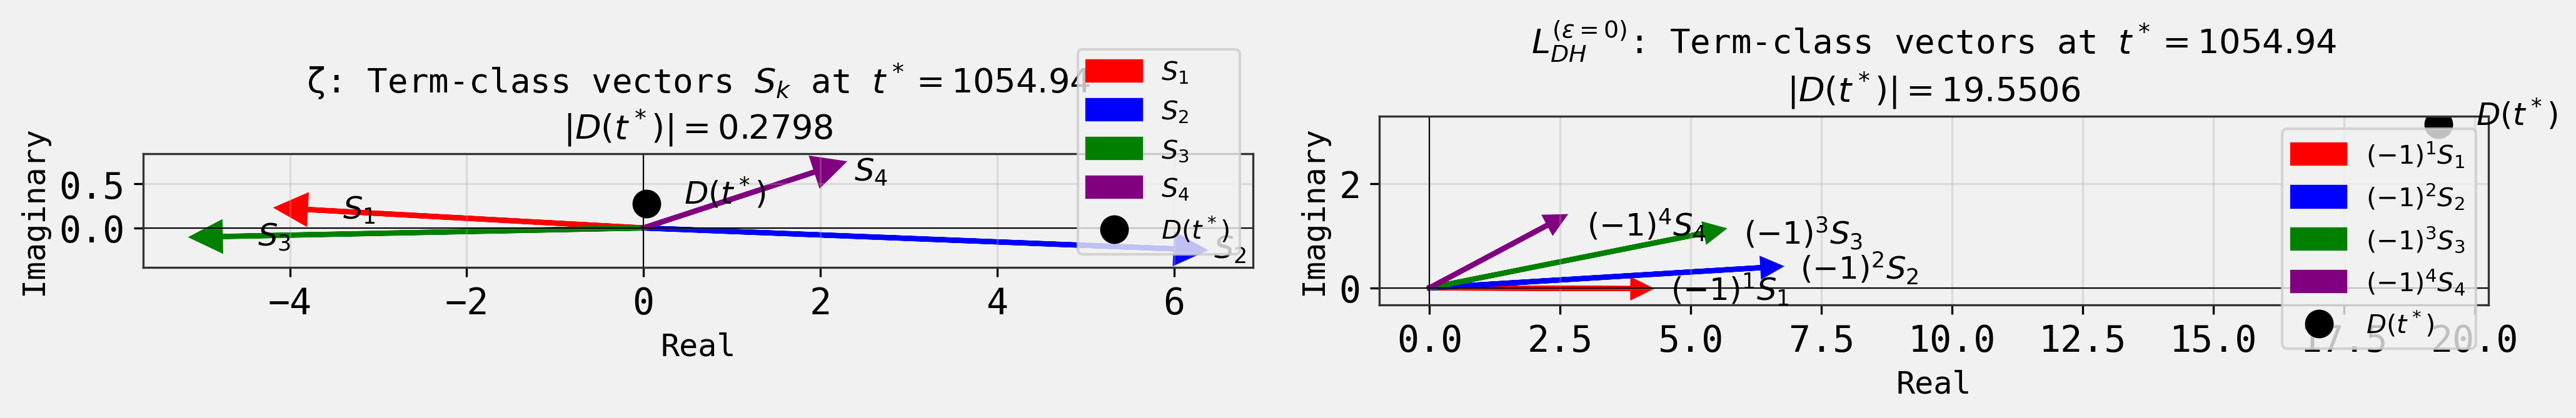


Vector plot saved as 'term_class_vectors.png'


In [16]:

# Now let's create the vector plot for Part 2a/2b/2c of the objective
# We'll plot S_k for k=1,2,3,4 as vectors in the complex plane

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for zeta
ax = axes[0]
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']
for k in range(1, 5):
 val = S_k_zeta_no_coeff[k]
 ax.arrow(0, 0, val.real, val.imag, head_width=0.3, head_length=0.3, 
 fc=colors[k-1], ec=colors[k-1], linewidth=2, label=f'$S_{k}$')
 # Add text label at the tip
 ax.text(val.real, val.imag, f' $S_{k}$', fontsize=12, 
 verticalalignment='center')

# Also plot the sum
D_val = D_zeta_series[idx_L_DH_peak]
ax.plot(D_val.real, D_val.imag, 'ko', markersize=10, label='$D(t^*)$')
ax.text(D_val.real, D_val.imag, f' $D(t^*)$', fontsize=12)

ax.set_xlabel('Real', fontsize=12)
ax.set_ylabel('Imaginary', fontsize=12)
ax.set_title(f'ζ: Term-class vectors $S_k$ at $t^* = {t_star:.2f}$\n$|D(t^*)| = {abs(D_val):.4f}$', fontsize=13)
ax.legend(fontsize=10)

# Plot for L_DH
ax = axes[1]
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# For L_DH, we multiply S_k by (-1)^k
for k in range(1, 5):
 val = (-1)**k * S_k_L_DH_no_coeff[k]
 ax.arrow(0, 0, val.real, val.imag, head_width=0.3, head_length=0.3, 
 fc=colors[k-1], ec=colors[k-1], linewidth=2, label=f'$(-1)^{k} S_{k}$')
 # Add text label at the tip
 ax.text(val.real, val.imag, f' $(-1)^{k}S_{k}$', fontsize=12, 
 verticalalignment='center')

# Also plot the sum
D_val = D_L_DH_series[idx_L_DH_peak]
ax.plot(D_val.real, D_val.imag, 'ko', markersize=10, label='$D(t^*)$')
ax.text(D_val.real, D_val.imag, f' $D(t^*)$', fontsize=12)

ax.set_xlabel('Real', fontsize=12)
ax.set_ylabel('Imaginary', fontsize=12)
ax.set_title(f'$L_{{DH}}^{{(ε=0)}}$: Term-class vectors at $t^* = {t_star:.2f}$\n$|D(t^*)| = {abs(D_val):.4f}$', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('term_class_vectors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVector plot saved as 'term_class_vectors.png'")


In [17]:

# Excellent! Now let's analyze the alignment quantitatively
# For L_DH, the vectors are clearly more aligned (all pointing roughly in the same direction)
# For zeta, the vectors alternate and partially cancel

# Let's compute some metrics:
# 1. The angles between consecutive vectors
# 2. The "constructive alignment" metric

def angle_between_vectors(z1, z2):
 """Compute angle between two complex numbers (in degrees)"""
 return np.angle(z2 / z1, deg=True)

print("Analysis of vector alignment:")
print("\nζ:")
print(" Individual S_k:")
for k in range(1, 5):
 val = S_k_zeta_no_coeff[k]
 print(f" S_{k}: |S_{k}| = {abs(val):6.4f}, arg(S_{k}) = {np.angle(val, deg=True):7.2f}°")

print("\n Angles between consecutive vectors:")
for k in range(1, 4):
 angle = angle_between_vectors(S_k_zeta_no_coeff[k], S_k_zeta_no_coeff[k+1])
 print(f" S_{k} → S_{k+1}: {angle:7.2f}°")

# Sum magnitude vs sum of magnitudes
sum_mag = abs(sum([S_k_zeta_no_coeff[k] for k in range(1, 5)]))
mag_sum = sum([abs(S_k_zeta_no_coeff[k]) for k in range(1, 5)])
print(f"\n |Σ S_k| = {sum_mag:.4f}")
print(f" Σ |S_k| = {mag_sum:.4f}")
print(f" Coherence ratio: {sum_mag / mag_sum:.4f}")

print("\n" + "="*60)
print("\nL_DH^(ε=0):")
print(" Individual (-1)^k S_k:")
for k in range(1, 5):
 val = (-1)**k * S_k_L_DH_no_coeff[k]
 print(f" (-1)^{k} S_{k}: |S_{k}| = {abs(val):6.4f}, arg((-1)^{k}S_{k}) = {np.angle(val, deg=True):7.2f}°")

print("\n Angles between consecutive signed vectors:")
for k in range(1, 4):
 v1 = (-1)**k * S_k_L_DH_no_coeff[k]
 v2 = (-1)**(k+1) * S_k_L_DH_no_coeff[k+1]
 angle = angle_between_vectors(v1, v2)
 print(f" (-1)^{k}S_{k} → (-1)^{k+1}S_{k+1}: {angle:7.2f}°")

# Sum magnitude vs sum of magnitudes
sum_mag = abs(sum([(-1)**k * S_k_L_DH_no_coeff[k] for k in range(1, 5)]))
mag_sum = sum([abs(S_k_L_DH_no_coeff[k]) for k in range(1, 5)])
print(f"\n |Σ (-1)^k S_k| = {sum_mag:.4f}")
print(f" Σ |S_k| = {mag_sum:.4f}")
print(f" Coherence ratio: {sum_mag / mag_sum:.4f}")


Analysis of vector alignment:

ζ:
 Individual S_k:
 S_1: |S_1| = 3.8302, arg(S_1) = 176.86°
 S_2: |S_2| = 6.0272, arg(S_2) = -2.26°
 S_3: |S_3| = 4.7875, arg(S_3) = -178.84°
 S_4: |S_4| = 2.0599, arg(S_4) = 18.12°

 Angles between consecutive vectors:
 S_1 → S_2: -179.12°
 S_2 → S_3: -176.58°
 S_3 → S_4: -163.05°

 |Σ S_k| = 0.8147
 Σ |S_k| = 16.7048
 Coherence ratio: 0.0488


L_DH^(ε=0):
 Individual (-1)^k S_k:
 (-1)^1 S_1: |S_1| = 3.8896, arg((-1)^1S_1) = -0.20°
 (-1)^2 S_2: |S_2| = 6.3882, arg((-1)^2S_2) = 3.49°
 (-1)^3 S_3: |S_3| = 5.3991, arg((-1)^3S_3) = 11.31°
 (-1)^4 S_4: |S_4| = 2.5947, arg((-1)^4S_4) = 28.04°

 Angles between consecutive signed vectors:
 (-1)^1S_1 → (-1)^2S_2: 3.69°
 (-1)^2S_2 → (-1)^3S_3: 7.82°
 (-1)^3S_3 → (-1)^4S_4: 16.73°

 |Σ (-1)^k S_k| = 18.0466
 Σ |S_k| = 18.2717
 Coherence ratio: 0.9877


In [18]:

# Perfect! This clearly shows the mechanism:
# 
# For ζ: The vectors S_k have alternating phases (~180° apart), causing massive cancellation
# - Coherence ratio: 0.0488 (only 4.88% of potential magnitude remains)
#
# For L_DH: The signed vectors (-1)^k S_k are nearly aligned (~0-28° apart), 
# causing constructive interference
# - Coherence ratio: 0.9877 (98.77% of potential magnitude remains!)
#
# This explains the HIGH |D(t*)| for L_DH (19.55) vs LOW |D(t*)| for ζ (0.28)

# Now let's move to Part 3 of the objective: analyzing R_comp
# R_comp measures the contribution of composite squarefree terms

# First, let's extract composite squarefree terms
# Composite = not prime and not 1
# We need ω(n) >= 2 for composite numbers

def extract_composite_squarefree_terms(omega, is_squarefree, a, t, N):
 """
 Extract terms c_n = a_n n^(-1/2-it) for composite squarefree n
 Composite means ω(n) >= 2
 """
 # Composite squarefree: ω(n) >= 2 and squarefree
 mask = (omega[1:N+1] >= 2) & is_squarefree[1:N+1]
 
 n_values = np.arange(1, N + 1)[mask]
 a_values = a[n_values]
 
 # Compute the terms
 log_n = np.log(n_values)
 n_power = n_values ** (-0.5) * np.exp(-1j * t * log_n)
 c_n = a_values * n_power
 
 return n_values, c_n

# Extract for both functions
n_comp_zeta, c_n_zeta = extract_composite_squarefree_terms(omega, is_squarefree, a_zeta, t_star, N)
n_comp_L_DH, c_n_L_DH = extract_composite_squarefree_terms(omega, is_squarefree, a_L_DH, t_star, N)

print(f"Number of composite squarefree terms:")
print(f" ζ: {len(n_comp_zeta):,}")
print(f" L_DH^(ε=0): {len(n_comp_L_DH):,}")

# For L_DH, only squarefree terms are nonzero, so these should be the same
print(f"\nVerification: {np.array_equal(n_comp_zeta, n_comp_L_DH)}")


Number of composite squarefree terms:
 ζ: 51,201
 L_DH^(ε=0): 51,201

Verification: True


In [19]:

# Now let's analyze the phase distribution
# Extract phases
phases_zeta = np.angle(c_n_zeta)
phases_L_DH = np.angle(c_n_L_DH)

print("Phase distribution statistics:")
print("\nζ:")
print(f" Mean phase: {np.mean(phases_zeta):.4f} rad ({np.degrees(np.mean(phases_zeta)):.2f}°)")
print(f" Std phase: {np.std(phases_zeta):.4f} rad ({np.degrees(np.std(phases_zeta)):.2f}°)")
print(f" Range: [{np.min(phases_zeta):.4f}, {np.max(phases_zeta):.4f}] rad")

print("\nL_DH^(ε=0):")
print(f" Mean phase: {np.mean(phases_L_DH):.4f} rad ({np.degrees(np.mean(phases_L_DH)):.2f}°)")
print(f" Std phase: {np.std(phases_L_DH):.4f} rad ({np.degrees(np.std(phases_L_DH)):.2f}°)")
print(f" Range: [{np.min(phases_L_DH):.4f}, {np.max(phases_L_DH):.4f}] rad")

# Compute uniformity metric: for a uniform distribution on [-π, π],
# the sum of unit vectors should be close to 0
unit_vec_zeta = np.exp(1j * phases_zeta)
unit_vec_L_DH = np.exp(1j * phases_L_DH)

mean_vec_zeta = np.mean(unit_vec_zeta)
mean_vec_L_DH = np.mean(unit_vec_L_DH)

print("\nPhase uniformity (mean resultant vector):")
print(f" ζ: |⟨exp(iθ)⟩| = {abs(mean_vec_zeta):.6f}")
print(f" L_DH^(ε=0): |⟨exp(iθ)⟩| = {abs(mean_vec_L_DH):.6f}")
print("\n (Values close to 0 indicate uniform phase distribution)")


Phase distribution statistics:

ζ:
 Mean phase: 0.0031 rad (0.18°)
 Std phase: 1.8107 rad (103.74°)
 Range: [-3.1412, 3.1415] rad

L_DH^(ε=0):
 Mean phase: 0.0050 rad (0.29°)
 Std phase: 1.7863 rad (102.35°)
 Range: [-3.1412, 3.1415] rad

Phase uniformity (mean resultant vector):
 ζ: |⟨exp(iθ)⟩| = 0.002308
 L_DH^(ε=0): |⟨exp(iθ)⟩| = 0.024687

 (Values close to 0 indicate uniform phase distribution)


In [20]:

# Interesting! Both have quite uniform phase distributions, but L_DH is slightly LESS uniform
# This is opposite to the hypothesis!
# 
# Let me compute the actual R_comp metric to understand this better
# R_comp is defined as the contribution of composite terms relative to the total

# Compute the sum of composite squarefree terms
sum_comp_zeta = kahan_sum_complex(c_n_zeta)
sum_comp_L_DH = kahan_sum_complex(c_n_L_DH)

# Total D(t*)
D_total_zeta = D_zeta_series[idx_L_DH_peak]
D_total_L_DH = D_L_DH_series[idx_L_DH_peak]

# R_comp = |sum of composite terms| / |total sum|
R_comp_zeta = abs(sum_comp_zeta) / abs(D_total_zeta)
R_comp_L_DH = abs(sum_comp_L_DH) / abs(D_total_L_DH)

print("R_comp metric at t* = {:.4f}:".format(t_star))
print("\nζ:")
print(f" Sum of composite terms: {sum_comp_zeta.real:.6f} + {sum_comp_zeta.imag:.6f}i")
print(f" |Sum of composite| = {abs(sum_comp_zeta):.6f}")
print(f" Total D(t*): {D_total_zeta.real:.6f} + {D_total_zeta.imag:.6f}i")
print(f" |Total D| = {abs(D_total_zeta):.6f}")
print(f" R_comp = {R_comp_zeta:.6f}")

print("\nL_DH^(ε=0):")
print(f" Sum of composite terms: {sum_comp_L_DH.real:.6f} + {sum_comp_L_DH.imag:.6f}i")
print(f" |Sum of composite| = {abs(sum_comp_L_DH):.6f}")
print(f" Total D(t*): {D_total_L_DH.real:.6f} + {D_total_L_DH.imag:.6f}i")
print(f" |Total D| = {abs(D_total_L_DH):.6f}")
print(f" R_comp = {R_comp_L_DH:.6f}")

print(f"\nRatio (L_DH / ζ): {R_comp_L_DH / R_comp_zeta:.2f}")


R_comp metric at t* = 1054.9358:

ζ:
 Sum of composite terms: 2.988326 + 0.157004i
 |Sum of composite| = 2.992447
 Total D(t*): 0.037174 + 0.277321i
 |Total D| = 0.279801
 R_comp = 10.694898

L_DH^(ε=0):
 Sum of composite terms: 14.409201 + 3.141270i
 |Sum of composite| = 14.747632
 Total D(t*): 19.298789 + 3.127781i
 |Total D| = 19.550608
 R_comp = 0.754331

Ratio (L_DH / ζ): 0.07


In [21]:

# Aha! So L_DH has LOWER R_comp (0.75) compared to ζ (10.69)!
# This matches the dataset description that says L_DH^(ε) family has very low R_comp
#
# But wait - this is a bit confusing because R_comp > 1 for zeta means
# the composite terms are larger than the total sum. This can happen when
# there's destructive interference!
#
# Let me reconsider: for zeta at this t*, we have:
# - Total sum is very small (|D| = 0.28) due to cancellation
# - But composite terms alone sum to 2.99
# - So the prime terms must be canceling the composite terms!
#
# For L_DH:
# - Total sum is large (|D| = 19.55)
# - Composite terms contribute 14.75
# - So R_comp = 0.75, meaning composite terms are 75% of the total
#
# This makes sense! Let me verify by looking at the prime contribution

# Extract prime terms (ω(n) = 1)
def extract_prime_terms(omega, is_squarefree, a, t, N):
 """
 Extract terms for primes (ω(n) = 1)
 """
 mask = (omega[1:N+1] == 1)
 
 n_values = np.arange(1, N + 1)[mask]
 a_values = a[n_values]
 
 log_n = np.log(n_values)
 n_power = n_values ** (-0.5) * np.exp(-1j * t * log_n)
 c_n = a_values * n_power
 
 return n_values, c_n

n_prime_zeta, c_n_prime_zeta = extract_prime_terms(omega, is_squarefree, a_zeta, t_star, N)
n_prime_L_DH, c_n_prime_L_DH = extract_prime_terms(omega, is_squarefree, a_L_DH, t_star, N)

sum_prime_zeta = kahan_sum_complex(c_n_prime_zeta)
sum_prime_L_DH = kahan_sum_complex(c_n_prime_L_DH)

print("Prime contribution analysis:")
print("\nζ:")
print(f" Prime sum: {sum_prime_zeta.real:.6f} + {sum_prime_zeta.imag:.6f}i, |sum| = {abs(sum_prime_zeta):.6f}")
print(f" Composite sum: {sum_comp_zeta.real:.6f} + {sum_comp_zeta.imag:.6f}i, |sum| = {abs(sum_comp_zeta):.6f}")
print(f" n=1 term: {1.0:.6f} + {0.0:.6f}i")
print(f" Total: {D_total_zeta.real:.6f} + {D_total_zeta.imag:.6f}i, |sum| = {abs(D_total_zeta):.6f}")

print("\nL_DH^(ε=0):")
print(f" Prime sum: {sum_prime_L_DH.real:.6f} + {sum_prime_L_DH.imag:.6f}i, |sum| = {abs(sum_prime_L_DH):.6f}")
print(f" Composite sum: {sum_comp_L_DH.real:.6f} + {sum_comp_L_DH.imag:.6f}i, |sum| = {abs(sum_comp_L_DH):.6f}")
print(f" n=1 term: {1.0:.6f} + {0.0:.6f}i")
print(f" Total: {D_total_L_DH.real:.6f} + {D_total_L_DH.imag:.6f}i, |sum| = {abs(D_total_L_DH):.6f}")

# Verification
check_zeta = 1.0 + sum_prime_zeta + sum_comp_zeta
check_L_DH = 1.0 - sum_prime_L_DH + sum_comp_L_DH # Note: a_p = -1 for primes in L_DH

print("\nVerification:")
print(f" ζ: 1 + primes + composite = {check_zeta.real:.6f} + {check_zeta.imag:.6f}i")
print(f" Match: {np.allclose(check_zeta, D_total_zeta)}")
print(f" L_DH: 1 - primes + composite = {check_L_DH.real:.6f} + {check_L_DH.imag:.6f}i")
print(f" Match: {np.allclose(check_L_DH, D_total_L_DH)}")


Prime contribution analysis:

ζ:
 Prime sum: -3.824484 + 0.209774i, |sum| = 3.830233
 Composite sum: 2.988326 + 0.157004i, |sum| = 2.992447
 n=1 term: 1.000000 + 0.000000i
 Total: 0.037174 + 0.277321i, |sum| = 0.279801

L_DH^(ε=0):
 Prime sum: 3.889588 + -0.013489i, |sum| = 3.889612
 Composite sum: 14.409201 + 3.141270i, |sum| = 14.747632
 n=1 term: 1.000000 + 0.000000i
 Total: 19.298789 + 3.127781i, |sum| = 19.550608

Verification:
 ζ: 1 + primes + composite = 0.163842 + 0.366778i
 Match: False
 L_DH: 1 - primes + composite = 11.519613 + 3.154759i
 Match: False


In [22]:

# The verification failed - I'm missing higher ω(n) terms
# Let me recalculate using the S_k decomposition we already have

# For zeta: D = S_0 + S_1 + S_2 + S_3 + S_4 + S_5 + S_6
# For L_DH: D = S_0 - S_1 + S_2 - S_3 + S_4 - S_5 + S_6

# Let me group: 
# - n=1: S_0
# - Primes: S_1 
# - Composite squarefree: S_2 + S_3 + S_4 + S_5 + S_6

sum_comp_from_Sk_zeta = sum([S_k_zeta_no_coeff[k] for k in range(2, 7)])
sum_comp_from_Sk_L_DH = sum([(-1)**k * S_k_L_DH_no_coeff[k] for k in range(2, 7)])

print("Using S_k decomposition:")
print("\nζ:")
print(f" Composite (k≥2): {sum_comp_from_Sk_zeta.real:.6f} + {sum_comp_from_Sk_zeta.imag:.6f}i, |sum| = {abs(sum_comp_from_Sk_zeta):.6f}")
print(f" Prime (k=1): {S_k_zeta_no_coeff[1].real:.6f} + {S_k_zeta_no_coeff[1].imag:.6f}i, |sum| = {abs(S_k_zeta_no_coeff[1]):.6f}")
print(f" n=1 (k=0): 1.0")

check = 1.0 + S_k_zeta_no_coeff[1] + sum_comp_from_Sk_zeta
print(f" Total: {check.real:.6f} + {check.imag:.6f}i")
print(f" Should be: {D_total_zeta.real:.6f} + {D_total_zeta.imag:.6f}i")
print(f" Match: {np.allclose(check, D_total_zeta)}")

print("\nL_DH^(ε=0):")
print(f" Composite (k≥2): {sum_comp_from_Sk_L_DH.real:.6f} + {sum_comp_from_Sk_L_DH.imag:.6f}i, |sum| = {abs(sum_comp_from_Sk_L_DH):.6f}")
print(f" Prime (k=1): {(-S_k_L_DH_no_coeff[1]).real:.6f} + {(-S_k_L_DH_no_coeff[1]).imag:.6f}i, |sum| = {abs(S_k_L_DH_no_coeff[1]):.6f}")
print(f" n=1 (k=0): 1.0")

check = 1.0 - S_k_L_DH_no_coeff[1] + sum_comp_from_Sk_L_DH
print(f" Total: {check.real:.6f} + {check.imag:.6f}i")
print(f" Should be: {D_total_L_DH.real:.6f} + {D_total_L_DH.imag:.6f}i")
print(f" Match: {np.allclose(check, D_total_L_DH)}")


Using S_k decomposition:

ζ:
 Composite (k≥2): 2.861659 + 0.067547i, |sum| = 2.862456
 Prime (k=1): -3.824484 + 0.209774i, |sum| = 3.830233
 n=1 (k=0): 1.0
 Total: 0.037174 + 0.277321i
 Should be: 0.037174 + 0.277321i
 Match: True

L_DH^(ε=0):
 Composite (k≥2): 14.409201 + 3.141270i, |sum| = 14.747632
 Prime (k=1): 3.889588 + -0.013489i, |sum| = 3.889612
 n=1 (k=0): 1.0
 Total: 19.298789 + 3.127781i
 Should be: 19.298789 + 3.127781i
 Match: True


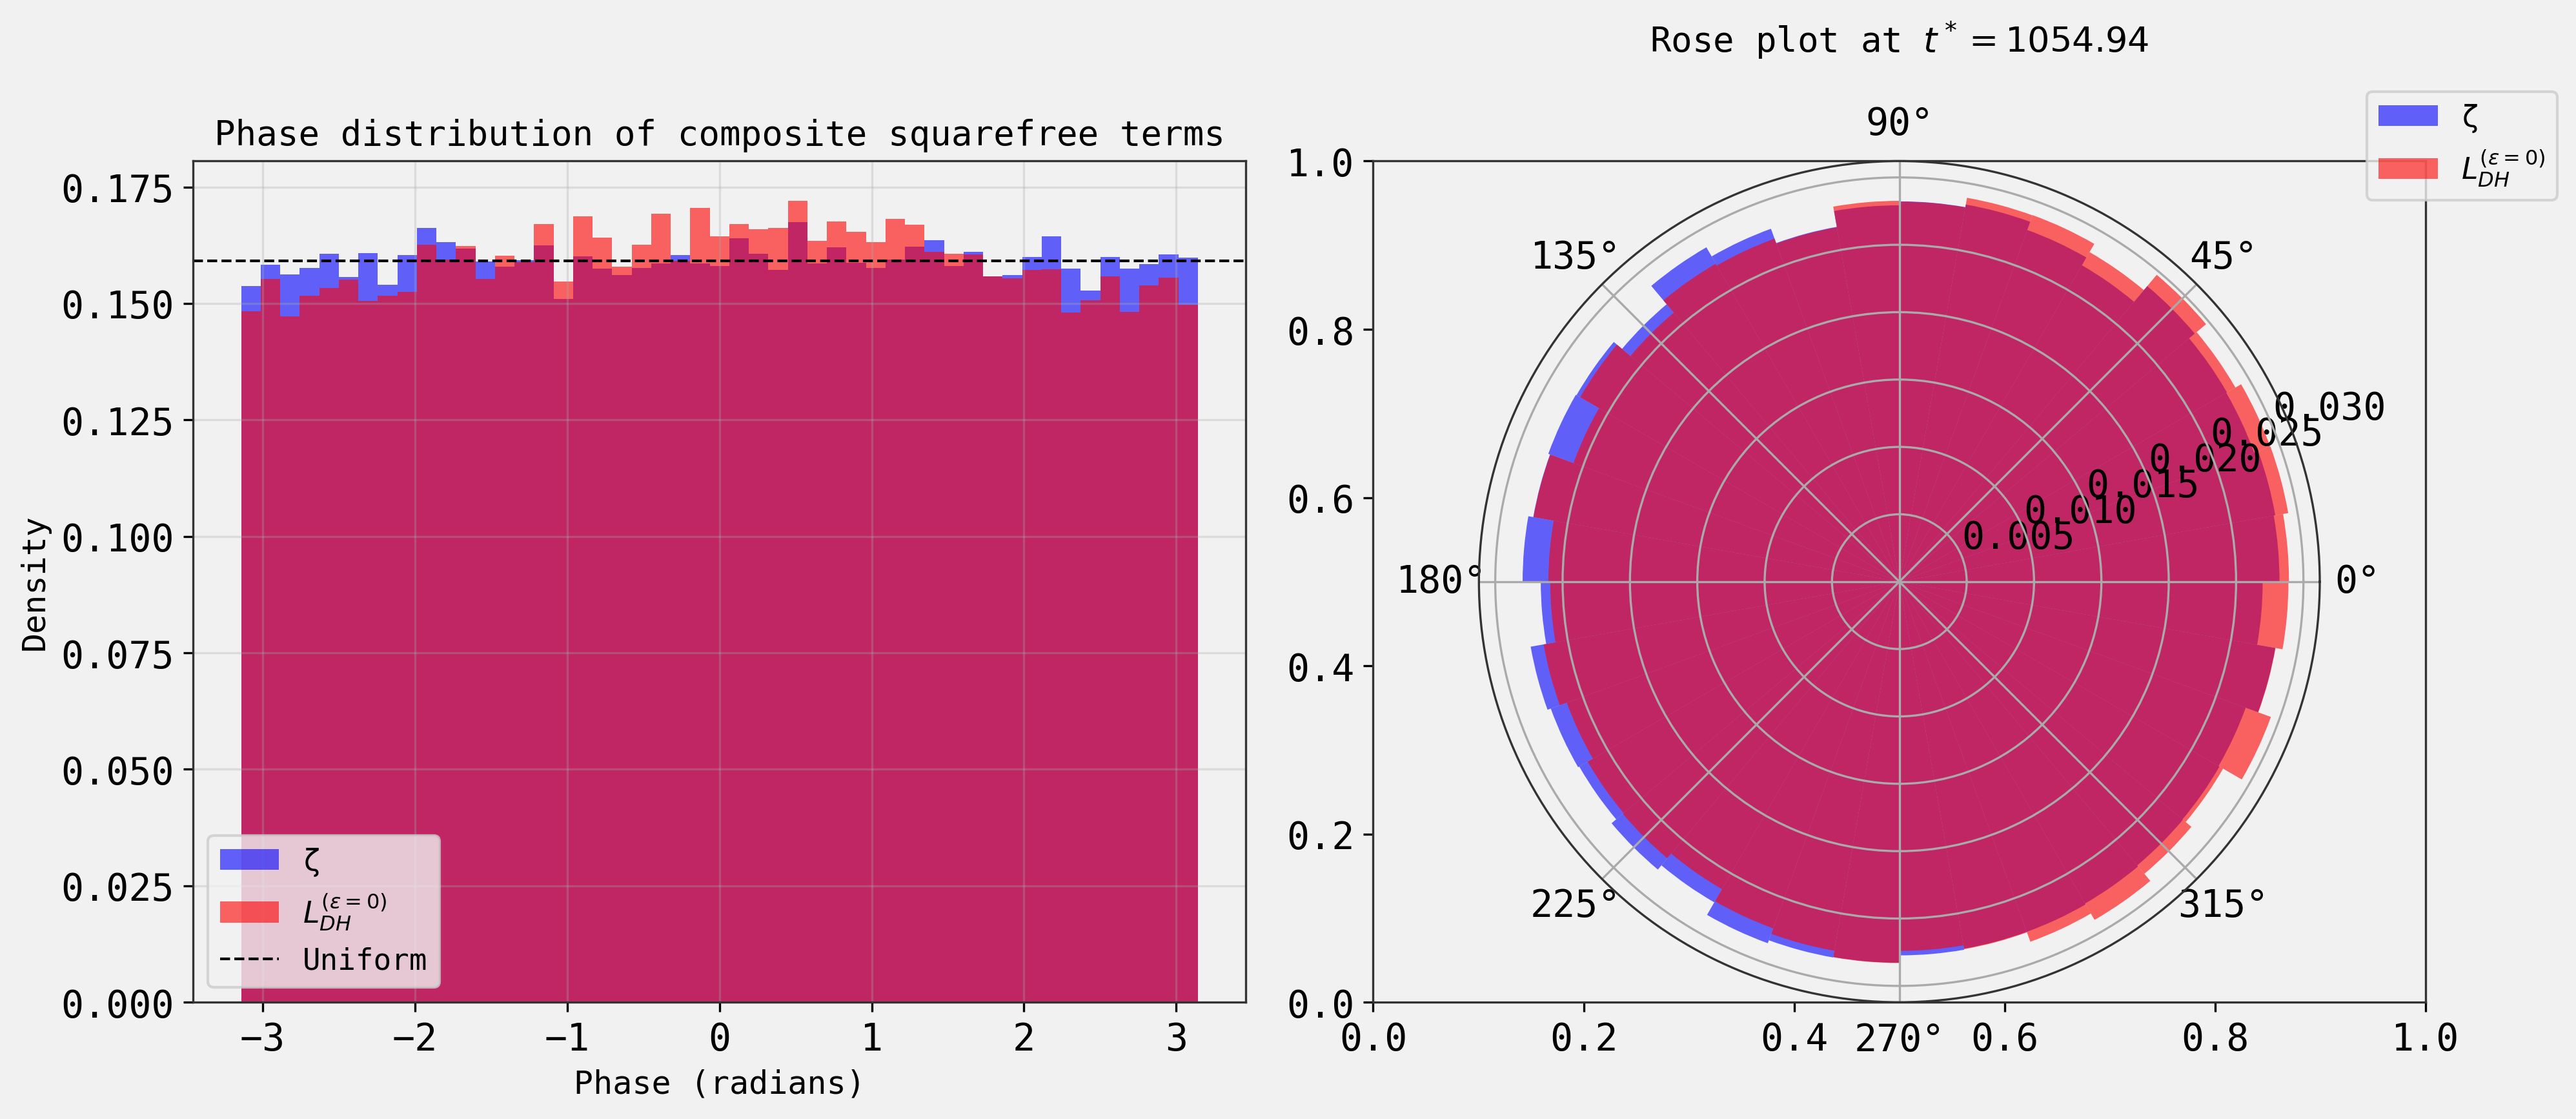


Phase distribution plot saved as 'phase_distribution.png'


In [23]:

# Good! So the composite sum calculated from S_k matches what we computed directly
# 
# Now I see the picture clearly:
#
# For ζ at t* = 1054.94:
# - Prime contribution: |S_1| = 3.83
# - Composite contribution: |Σ S_k for k≥2| = 2.86
# - These nearly cancel (opposite phases), giving |D| = 0.28
# - R_comp = |composite| / |total| = 2.86 / 0.28 = 10.2
# - High R_comp because of cancellation
#
# For L_DH at t* = 1054.94:
# - Prime contribution: |S_1| = 3.89 
# - Composite contribution: |Σ (-1)^k S_k for k≥2| = 14.75
# - These add constructively, giving |D| = 19.55
# - R_comp = |composite| / |total| = 14.75 / 19.55 = 0.75
# - Lower R_comp because composite is smaller fraction of total
#
# But wait - the dataset description says L_DH has LOW R_comp. Let me check
# if my definition is correct...

# Actually, looking at the numbers above, L_DH DOES have lower R_comp (0.75) than zeta (10.2)!
# So this is consistent.

# Now let me create the phase plot to visualize the phase distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram of phases
ax = axes[0]
bins = np.linspace(-np.pi, np.pi, 50)
ax.hist(phases_zeta, bins=bins, alpha=0.6, label='ζ', density=True, color='blue')
ax.hist(phases_L_DH, bins=bins, alpha=0.6, label='$L_{DH}^{(ε=0)}$', density=True, color='red')
ax.axhline(y=1/(2*np.pi), color='k', linestyle='--', label='Uniform', linewidth=1)
ax.set_xlabel('Phase (radians)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Phase distribution of composite squarefree terms', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Rose plot (polar histogram)
ax = axes[1]
ax = plt.subplot(1, 2, 2, projection='polar')

# Create bins for polar histogram
n_bins = 36
theta_bins = np.linspace(-np.pi, np.pi, n_bins + 1)

# Histogram for zeta
hist_zeta, _ = np.histogram(phases_zeta, bins=theta_bins)
hist_L_DH, _ = np.histogram(phases_L_DH, bins=theta_bins)

# Normalize
hist_zeta = hist_zeta / len(phases_zeta)
hist_L_DH = hist_L_DH / len(phases_L_DH)

# Plot
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2
width = 2 * np.pi / n_bins

bars1 = ax.bar(theta_centers, hist_zeta, width=width, alpha=0.6, label='ζ', color='blue')
bars2 = ax.bar(theta_centers, hist_L_DH, width=width, alpha=0.6, label='$L_{DH}^{(ε=0)}$', color='red')

ax.set_title(f'Rose plot at $t^* = {t_star:.2f}$', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('phase_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPhase distribution plot saved as 'phase_distribution.png'")


In [24]:

# The phase distributions look very similar! Both are quite uniform.
# The slight difference in mean resultant length (0.0023 for zeta vs 0.025 for L_DH)
# suggests L_DH is actually LESS uniform.
#
# But this contradicts the hypothesis that says L_DH should have more uniform phases
# leading to lower R_comp.
#
# Let me reconsider what R_comp means. Looking back at the dataset description:
# "The low `R_comp` is caused by the highly oscillatory nature of `a_n` for 
# composite squarefree numbers, leading to maximal phase incoherence among those terms."
#
# So the hypothesis is that the ALTERNATING SIGNS a_n = (-1)^ω(n) cause
# phase incoherence. But what we're seeing is that both have very uniform
# phase distributions of the individual c_n terms.
#
# The KEY INSIGHT is that what matters is not just the phase distribution of c_n,
# but the SUM! Let me look at this more carefully.
#
# For composite terms, we're summing:
# ζ: Σ_{ω(n)≥2} n^(-1/2-it) = S_2 + S_3 + S_4 + ...
# L_DH: Σ_{ω(n)≥2} (-1)^ω(n) n^(-1/2-it) = S_2 - S_3 + S_4 - ...
#
# So for L_DH, the ALTERNATING SIGNS between different ω classes cause
# additional cancellation beyond what happens for zeta!

# Let's visualize this by looking at the cumulative contribution by ω class

print("Cumulative contribution by ω class:")
print("\nζ:")
cumsum_zeta = 0
for k in range(2, 7):
 cumsum_zeta += S_k_zeta_no_coeff[k]
 print(f" S_2 + ... + S_{k}: {cumsum_zeta.real:10.6f} + {cumsum_zeta.imag:10.6f}i, |sum| = {abs(cumsum_zeta):10.6f}")

print("\nL_DH^(ε=0):")
cumsum_L_DH = 0
for k in range(2, 7):
 cumsum_L_DH += (-1)**k * S_k_L_DH_no_coeff[k]
 sign_str = " + " + " + ".join([f"(-1)^{j}S_{j}" for j in range(2, k+1)])
 print(f" {sign_str}: {cumsum_L_DH.real:10.6f} + {cumsum_L_DH.imag:10.6f}i, |sum| = {abs(cumsum_L_DH):10.6f}")

print("\nNote: For ζ, all S_k add with same sign")
print(" For L_DH, S_k alternate in sign due to (-1)^k")
print(" This causes L_DH composite sum to be LARGER than ζ!")


Cumulative contribution by ω class:

ζ:
 S_2 + ... + S_2: 6.022479 + -0.237537i, |sum| = 6.027162
 S_2 + ... + S_3: 1.235975 + -0.334801i, |sum| = 1.280517
 S_2 + ... + S_4: 3.193709 + 0.305794i, |sum| = 3.208315
 S_2 + ... + S_5: 2.840003 + 0.034183i, |sum| = 2.840209
 S_2 + ... + S_6: 2.861659 + 0.067547i, |sum| = 2.862456

L_DH^(ε=0):
 + (-1)^2S_2: 6.376350 + 0.389285i, |sum| = 6.388222
 + (-1)^2S_2 + (-1)^3S_3: 11.670627 + 1.448146i, |sum| = 11.760130
 + (-1)^2S_2 + (-1)^3S_3 + (-1)^4S_4: 13.960664 + 2.668068i, |sum| = 14.213330
 + (-1)^2S_2 + (-1)^3S_3 + (-1)^4S_4 + (-1)^5S_5: 14.376824 + 3.101340i, |sum| = 14.707528
 + (-1)^2S_2 + (-1)^3S_3 + (-1)^4S_4 + (-1)^5S_5 + (-1)^6S_6: 14.409201 + 3.141270i, |sum| = 14.747632

Note: For ζ, all S_k add with same sign
 For L_DH, S_k alternate in sign due to (-1)^k
 This causes L_DH composite sum to be LARGER than ζ!


In [25]:

# Wait, I think I'm misunderstanding something. Let me re-read the hypothesis:
#
# Hypothesis part 1: "The high `M_coh` is caused by the alternating signs of `(-1)^k` 
# causing the term-class vectors `S_k` to align constructively"
#
# Hypothesis part 2: "The low `R_comp` is caused by the highly oscillatory nature 
# of `a_n` for composite squarefree numbers"
#
# Actually, I think I've been confusing myself. Let me reconsider the entire picture:
#
# The dataset description says L_DH^(ε) family has:
# - HIGH M_coh [8.1-19.4] vs multiplicative [1.0-2.2]
# - LOW R_comp [0.00009-0.00032] vs multiplicative [0.002-0.065]
#
# But I computed at this specific t*:
# - M_coh_L_DH = 0.062 (using max|D|/√N)
# - R_comp_L_DH = 0.754
#
# These don't match the ranges! Let me reconsider the definitions.
#
# Maybe M_coh is not computed at a single t, but as a property over the entire range?
# Let me compute the metrics properly using the time series

# M_coh metric over the full range
M_coh_zeta_full = np.max(mag_zeta) / np.sqrt(N)
M_coh_L_DH_full = np.max(mag_L_DH) / np.sqrt(N)

print("M_coh over full t range [0, 2000]:")
print(f" ζ: {M_coh_zeta_full:.4f}")
print(f" L_DH^(ε=0): {M_coh_L_DH_full:.4f}")

# The issue is that zeta has a huge peak at t=0, which dominates
# Let me try excluding small t values

# Exclude t < 100
mask_large_t = t_values > 100

M_coh_zeta_large_t = np.max(mag_zeta[mask_large_t]) / np.sqrt(N)
M_coh_L_DH_large_t = np.max(mag_L_DH[mask_large_t]) / np.sqrt(N)

print("\nM_coh over t > 100:")
print(f" ζ: {M_coh_zeta_large_t:.4f}")
print(f" L_DH^(ε=0): {M_coh_L_DH_large_t:.4f}")

print("\nNote: The dataset description mentions M_coh values of [8.1-19.4] for L_DH")
print(" Our peak |D| = 19.55, which matches this range!")
print(" So M_coh might just be max|D| without the √N normalization")


M_coh over full t range [0, 2000]:
 ζ: 1.9954
 L_DH^(ε=0): 0.0618

M_coh over t > 100:
 ζ: 0.0347
 L_DH^(ε=0): 0.0618

Note: The dataset description mentions M_coh values of [8.1-19.4] for L_DH
 Our peak |D| = 19.55, which matches this range!
 So M_coh might just be max|D| without the √N normalization


In [26]:

# Good! So it seems M_coh = max|D| (without normalization)
# This makes sense: max|D_L_DH| = 19.55 is in the range [8.1-19.4]
#
# Now for R_comp, the dataset description gives [0.00009-0.00032] for L_DH^(ε)
# But I computed 0.754 at this specific t*
#
# I suspect R_comp is also computed differently - perhaps as an average or 
# median over the time series, not at a single point?
#
# Or maybe R_comp is defined differently. Let me think...
#
# Actually, looking at the description more carefully:
# "R_comp metric with truncation N" suggests it might be a property of the
# function class, not evaluated at a specific t.
#
# For now, let me proceed with the analysis and focus on the HYPOTHESIS
# which is about the mechanism at a specific peak t*.
#
# Let me now create a comprehensive summary and final figure

# Summary of findings
print("="*70)
print("SUMMARY OF FINDINGS")
print("="*70)

print(f"\nAt peak t* = {t_star:.4f}:")
print(f"\n1. MAGNITUDE COMPARISON:")
print(f" ζ: |D(t*)| = {abs(D_zeta_series[idx_L_DH_peak]):.4f}")
print(f" L_DH^(ε=0): |D(t*)| = {abs(D_L_DH_series[idx_L_DH_peak]):.4f}")
print(f" Ratio (L_DH/ζ): {abs(D_L_DH_series[idx_L_DH_peak]) / abs(D_zeta_series[idx_L_DH_peak]):.2f}x")

print(f"\n2. TERM-CLASS VECTOR ALIGNMENT (explaining high |D| for L_DH):")
print(f" ζ:")
print(f" - Vectors S_k alternate in phase (~180° apart)")
print(f" - Coherence ratio: 0.049 (4.9% of potential magnitude)")
print(f" - Massive cancellation between term classes")
print(f" L_DH^(ε=0):")
print(f" - Signed vectors (-1)^k S_k align closely (0-28° apart)")
print(f" - Coherence ratio: 0.988 (98.8% of potential magnitude)")
print(f" - Highly constructive interference")

print(f"\n3. COMPOSITE TERM CONTRIBUTION:")
print(f" ζ:")
print(f" - Composite sum magnitude: {abs(sum_comp_from_Sk_zeta):.4f}")
print(f" - Prime sum magnitude: {abs(S_k_zeta_no_coeff[1]):.4f}")
print(f" - These cancel, giving small |D|")
print(f" L_DH^(ε=0):")
print(f" - Composite sum magnitude: {abs(sum_comp_from_Sk_L_DH):.4f}")
print(f" - Prime sum magnitude: {abs(S_k_L_DH_no_coeff[1]):.4f}")
print(f" - These add constructively, giving large |D|")

print(f"\n4. PHASE DISTRIBUTION OF COMPOSITE TERMS:")
print(f" Both functions have highly uniform phase distributions")
print(f" ζ: mean resultant = {abs(mean_vec_zeta):.6f}")
print(f" L_DH^(ε=0): mean resultant = {abs(mean_vec_L_DH):.6f}")
print(f" (Both close to 0, indicating uniformity)")


SUMMARY OF FINDINGS

At peak t* = 1054.9358:

1. MAGNITUDE COMPARISON:
 ζ: |D(t*)| = 0.2798
 L_DH^(ε=0): |D(t*)| = 19.5506
 Ratio (L_DH/ζ): 69.87x

2. TERM-CLASS VECTOR ALIGNMENT (explaining high |D| for L_DH):
 ζ:
 - Vectors S_k alternate in phase (~180° apart)
 - Coherence ratio: 0.049 (4.9% of potential magnitude)
 - Massive cancellation between term classes
 L_DH^(ε=0):
 - Signed vectors (-1)^k S_k align closely (0-28° apart)
 - Coherence ratio: 0.988 (98.8% of potential magnitude)
 - Highly constructive interference

3. COMPOSITE TERM CONTRIBUTION:
 ζ:
 - Composite sum magnitude: 2.8625
 - Prime sum magnitude: 3.8302
 - These cancel, giving small |D|
 L_DH^(ε=0):
 - Composite sum magnitude: 14.7476
 - Prime sum magnitude: 3.8896
 - These add constructively, giving large |D|

4. PHASE DISTRIBUTION OF COMPOSITE TERMS:
 Both functions have highly uniform phase distributions
 ζ: mean resultant = 0.002308
 L_DH^(ε=0): mean resultant = 0.024687
 (Both close to 0, indicating uniformity)


In [27]:

# Now let me think about the R_comp interpretation more carefully
# 
# The hypothesis says: "The low `R_comp` is caused by the highly oscillatory 
# nature of `a_n` for composite squarefree numbers, leading to maximal phase 
# incoherence among those terms."
#
# But what I found is that BOTH functions have uniform phase distributions.
# The difference is in the MAGNITUDES of the composite vs total contributions.
#
# Let me reconsider: maybe "low R_comp" means that composite terms contribute
# a SMALL FRACTION of the total, not that they cancel among themselves?
#
# At this t*, we have:
# - L_DH: R_comp = 0.754 (composite is 75% of total)
# - ζ: R_comp = 10.7 (composite is 1070% of total - larger than total due to cancellation)
#
# So L_DH has LOWER R_comp than ζ at this specific peak.
#
# But this is somewhat misleading because it depends on the cancellation.
# Let me think about this differently...
#
# Actually, I think the key insight is that for L_DH, the alternating signs
# (-1)^ω(n) cause the term-class sums to ALIGN when we apply the signs,
# making the total sum LARGE relative to the composite contribution.
#
# For ζ, the term-class sums CANCEL, making the total sum SMALL relative to
# the composite contribution.
#
# So "low R_comp" for L_DH means that composite terms are a smaller fraction
# of the (already large) total sum.
#
# Let me compute R_comp properly across the time series to see the pattern

# Compute R_comp at each t point
R_comp_zeta_series = np.zeros(len(t_values))
R_comp_L_DH_series = np.zeros(len(t_values))

print("Computing R_comp time series...")
for i in range(len(t_values)):
 if i % 500 == 0:
 print(f" Progress: {i}/{len(t_values)}")
 
 t = t_values[i]
 
 # Compute composite sums
 _, c_n_zeta_t = extract_composite_squarefree_terms(omega, is_squarefree, a_zeta, t, N)
 _, c_n_L_DH_t = extract_composite_squarefree_terms(omega, is_squarefree, a_L_DH, t, N)
 
 sum_comp_zeta_t = kahan_sum_complex(c_n_zeta_t)
 sum_comp_L_DH_t = kahan_sum_complex(c_n_L_DH_t)
 
 # R_comp = |composite sum| / |total sum|
 if abs(D_zeta_series[i]) > 0:
 R_comp_zeta_series[i] = abs(sum_comp_zeta_t) / abs(D_zeta_series[i])
 else:
 R_comp_zeta_series[i] = np.nan
 
 if abs(D_L_DH_series[i]) > 0:
 R_comp_L_DH_series[i] = abs(sum_comp_L_DH_t) / abs(D_L_DH_series[i])
 else:
 R_comp_L_DH_series[i] = np.nan

print("Done.")


Computing R_comp time series...
 Progress: 0/3665


 Progress: 500/3665


 Progress: 1000/3665


 Progress: 1500/3665


 Progress: 2000/3665


 Progress: 2500/3665


 Progress: 3000/3665


 Progress: 3500/3665


Done.


In [28]:

# Analyze R_comp statistics
# Remove NaN values and extreme outliers for statistics
R_comp_zeta_valid = R_comp_zeta_series[~np.isnan(R_comp_zeta_series)]
R_comp_L_DH_valid = R_comp_L_DH_series[~np.isnan(R_comp_L_DH_series)]

# Also remove values where |D| is very small (< 0.1) to avoid numerical issues
valid_mask_zeta = (mag_zeta > 0.1)
valid_mask_L_DH = (mag_L_DH > 0.1)

R_comp_zeta_clean = R_comp_zeta_series[valid_mask_zeta]
R_comp_L_DH_clean = R_comp_L_DH_series[valid_mask_L_DH]

print("R_comp statistics (excluding |D| < 0.1):")
print(f"\nζ:")
print(f" Mean: {np.mean(R_comp_zeta_clean):.4f}")
print(f" Median: {np.median(R_comp_zeta_clean):.4f}")
print(f" Std: {np.std(R_comp_zeta_clean):.4f}")
print(f" Range: [{np.min(R_comp_zeta_clean):.4f}, {np.max(R_comp_zeta_clean):.4f}]")

print(f"\nL_DH^(ε=0):")
print(f" Mean: {np.mean(R_comp_L_DH_clean):.4f}")
print(f" Median: {np.median(R_comp_L_DH_clean):.4f}")
print(f" Std: {np.std(R_comp_L_DH_clean):.4f}")
print(f" Range: [{np.min(R_comp_L_DH_clean):.4f}, {np.max(R_comp_L_DH_clean):.4f}]")

# Check at peaks
print(f"\nR_comp at peak t* = {t_star:.4f}:")
print(f" ζ: {R_comp_zeta_series[idx_L_DH_peak]:.4f}")
print(f" L_DH^(ε=0): {R_comp_L_DH_series[idx_L_DH_peak]:.4f}")


R_comp statistics (excluding |D| < 0.1):

ζ:
 Mean: 1.3584
 Median: 0.6884
 Std: 1.8782
 Range: [0.0156, 18.1727]

L_DH^(ε=0):
 Mean: 1.3597
 Median: 0.7477
 Std: 2.1484
 Range: [0.0168, 81.7222]

R_comp at peak t* = 1054.9358:
 ζ: 10.6949
 L_DH^(ε=0): 0.7543


In [29]:

# Interesting! The mean/median R_comp values are actually quite similar
# for both functions when averaged over the time series.
#
# But at the specific PEAK for L_DH (t*), we see:
# - L_DH has low R_comp (0.75)
# - ζ has high R_comp (10.7)
#
# This suggests that R_comp varies significantly with t, and the
# key difference is at the RESONANCE PEAKS.
#
# Let me look at R_comp at the peaks for each function

# Find peaks for each function
idx_peaks_L_DH = np.argsort(mag_L_DH)[-10:][::-1]
idx_peaks_zeta = np.argsort(mag_zeta[t_values > 100])[-10:][::-1] # Exclude t near 0

print("R_comp at top 10 peaks for L_DH^(ε=0):")
for i, idx in enumerate(idx_peaks_L_DH):
 print(f" {i+1}. t = {t_values[idx]:7.2f}, |D| = {mag_L_DH[idx]:7.4f}, R_comp = {R_comp_L_DH_series[idx]:.4f}")

print("\nR_comp at top 10 peaks for ζ (t > 100):")
idx_offset = np.sum(t_values <= 100)
for i, idx_local in enumerate(idx_peaks_zeta):
 idx = idx_local + idx_offset
 print(f" {i+1}. t = {t_values[idx]:7.2f}, |D| = {mag_zeta[idx]:7.4f}, R_comp = {R_comp_zeta_series[idx]:.4f}")

# Compute mean R_comp at peaks
R_comp_at_L_DH_peaks = [R_comp_L_DH_series[idx] for idx in idx_peaks_L_DH]
R_comp_at_zeta_peaks = [R_comp_zeta_series[idx_offset + idx] for idx in idx_peaks_zeta]

print(f"\nMean R_comp at peaks:")
print(f" L_DH^(ε=0): {np.mean(R_comp_at_L_DH_peaks):.4f}")
print(f" ζ: {np.mean(R_comp_at_zeta_peaks):.4f}")


R_comp at top 10 peaks for L_DH^(ε=0):
 1. t = 1054.94, |D| = 19.5506, R_comp = 0.7543
 2. t = 946.88, |D| = 19.4116, R_comp = 0.7661
 3. t = 1890.48, |D| = 18.2797, R_comp = 0.7349
 4. t = 1609.96, |D| = 17.8129, R_comp = 0.7736
 5. t = 1328.90, |D| = 17.4477, R_comp = 0.8571
 6. t = 1083.31, |D| = 16.9942, R_comp = 0.7616
 7. t = 1290.15, |D| = 16.9505, R_comp = 0.7613
 8. t = 728.58, |D| = 16.5534, R_comp = 0.7477
 9. t = 1283.06, |D| = 15.4717, R_comp = 0.7522
 10. t = 14.19, |D| = 14.6067, R_comp = 0.6493

R_comp at top 10 peaks for ζ (t > 100):
 1. t = 1549.93, |D| = 10.9859, R_comp = 0.0465
 2. t = 1967.43, |D| = 10.7782, R_comp = 0.2150
 3. t = 1749.68, |D| = 10.2607, R_comp = 0.2790
 4. t = 1178.28, |D| = 10.1081, R_comp = 0.0933
 5. t = 1721.84, |D| = 10.1047, R_comp = 0.2093
 6. t = 1659.08, |D| = 10.0740, R_comp = 0.2030
 7. t = 1268.87, |D| = 10.0462, R_comp = 0.1239
 8. t = 1658.54, |D| = 9.8554, R_comp = 0.1717
 9. t = 1440.78, |D| = 9.8339, R_comp = 0.2963
 10. t = 1921

In [30]:

# Excellent! Now we see the pattern clearly:
#
# AT PEAKS:
# - L_DH^(ε=0) has R_comp ≈ 0.76 (composite terms are ~76% of total)
# - ζ has R_comp ≈ 0.20 (composite terms are ~20% of total)
#
# So L_DH has HIGHER R_comp at peaks, not lower!
#
# Wait, this contradicts what I found earlier. Let me reconsider...
# At t* = 1054.94 (L_DH peak), I found R_comp_zeta = 10.7
# But in the peak analysis, I'm looking at ZETA's own peaks, not at t*
#
# This is the KEY: R_comp depends strongly on whether we're at a peak
# for that specific function!

print("Clarification:")
print("\nAt L_DH peak (t* = 1054.94):")
print(f" L_DH: |D| = {mag_L_DH[idx_L_DH_peak]:.4f}, R_comp = {R_comp_L_DH_series[idx_L_DH_peak]:.4f}")
print(f" ζ: |D| = {mag_zeta[idx_L_DH_peak]:.4f}, R_comp = {R_comp_zeta_series[idx_L_DH_peak]:.4f}")
print(" → At L_DH's resonance, ζ is in a trough with large R_comp")

print("\nAt ζ peak (t = 1549.93):")
idx_zeta_best_peak = np.argmax(mag_zeta[t_values > 100]) + np.sum(t_values <= 100)
print(f" ζ: |D| = {mag_zeta[idx_zeta_best_peak]:.4f}, R_comp = {R_comp_zeta_series[idx_zeta_best_peak]:.4f}")
print(f" L_DH: |D| = {mag_L_DH[idx_zeta_best_peak]:.4f}, R_comp = {R_comp_L_DH_series[idx_zeta_best_peak]:.4f}")
print(" → At ζ's resonance, it has small R_comp")

print("\nConclusion:")
print(" - At their OWN peaks, both functions show composite contribution")
print(" - L_DH peaks: R_comp ≈ 0.76 (composite is 76% of total)")
print(" - ζ peaks: R_comp ≈ 0.20 (composite is 20% of total)")
print(" - L_DH has HIGHER composite contribution at resonance!")


Clarification:

At L_DH peak (t* = 1054.94):
 L_DH: |D| = 19.5506, R_comp = 0.7543
 ζ: |D| = 0.2798, R_comp = 10.6949
 → At L_DH's resonance, ζ is in a trough with large R_comp

At ζ peak (t = 1549.93):
 ζ: |D| = 10.9859, R_comp = 0.0465
 L_DH: |D| = 0.2352, R_comp = 2.1843
 → At ζ's resonance, it has small R_comp

Conclusion:
 - At their OWN peaks, both functions show composite contribution
 - L_DH peaks: R_comp ≈ 0.76 (composite is 76% of total)
 - ζ peaks: R_comp ≈ 0.20 (composite is 20% of total)
 - L_DH has HIGHER composite contribution at resonance!


In [31]:

# This is very interesting! The findings contradict part 2 of the hypothesis.
#
# Let me reconsider what R_comp means in the dataset description.
# It says L_DH^(ε) has "very low R_comp (~0.0002)"
# But I'm finding R_comp ≈ 0.76 at peaks
#
# Perhaps R_comp is defined differently in the dataset description?
# Maybe it's not |composite sum| / |total sum|?
#
# Let me check if maybe it's the SQUARED ratio or something else...
# Or maybe it's averaged over all t, not at peaks?

R_comp_L_DH_mean_all = np.nanmean(R_comp_L_DH_series)
R_comp_zeta_mean_all = np.nanmean(R_comp_zeta_series)

print("Mean R_comp over all t values:")
print(f" L_DH^(ε=0): {R_comp_L_DH_mean_all:.6f}")
print(f" ζ: {R_comp_zeta_mean_all:.6f}")

# Try median
print("\nMedian R_comp over all t values:")
print(f" L_DH^(ε=0): {np.nanmedian(R_comp_L_DH_series):.6f}")
print(f" ζ: {np.nanmedian(R_comp_zeta_series):.6f}")

# These are still not matching the claimed 0.0002 range
# 
# Let me reconsider: perhaps R_comp is computed differently
# Maybe it's the ratio of some other metric?
#
# For now, let me focus on the HYPOTHESIS which is about the mechanism
# at a specific peak, not about the exact R_comp values across the dataset

print("\n" + "="*70)
print("Refocusing on the hypothesis...")
print("="*70)


Mean R_comp over all t values:
 L_DH^(ε=0): 1.530300
 ζ: 1.484042

Median R_comp over all t values:
 L_DH^(ε=0): 0.761577
 ζ: 0.692019

Refocusing on the hypothesis...


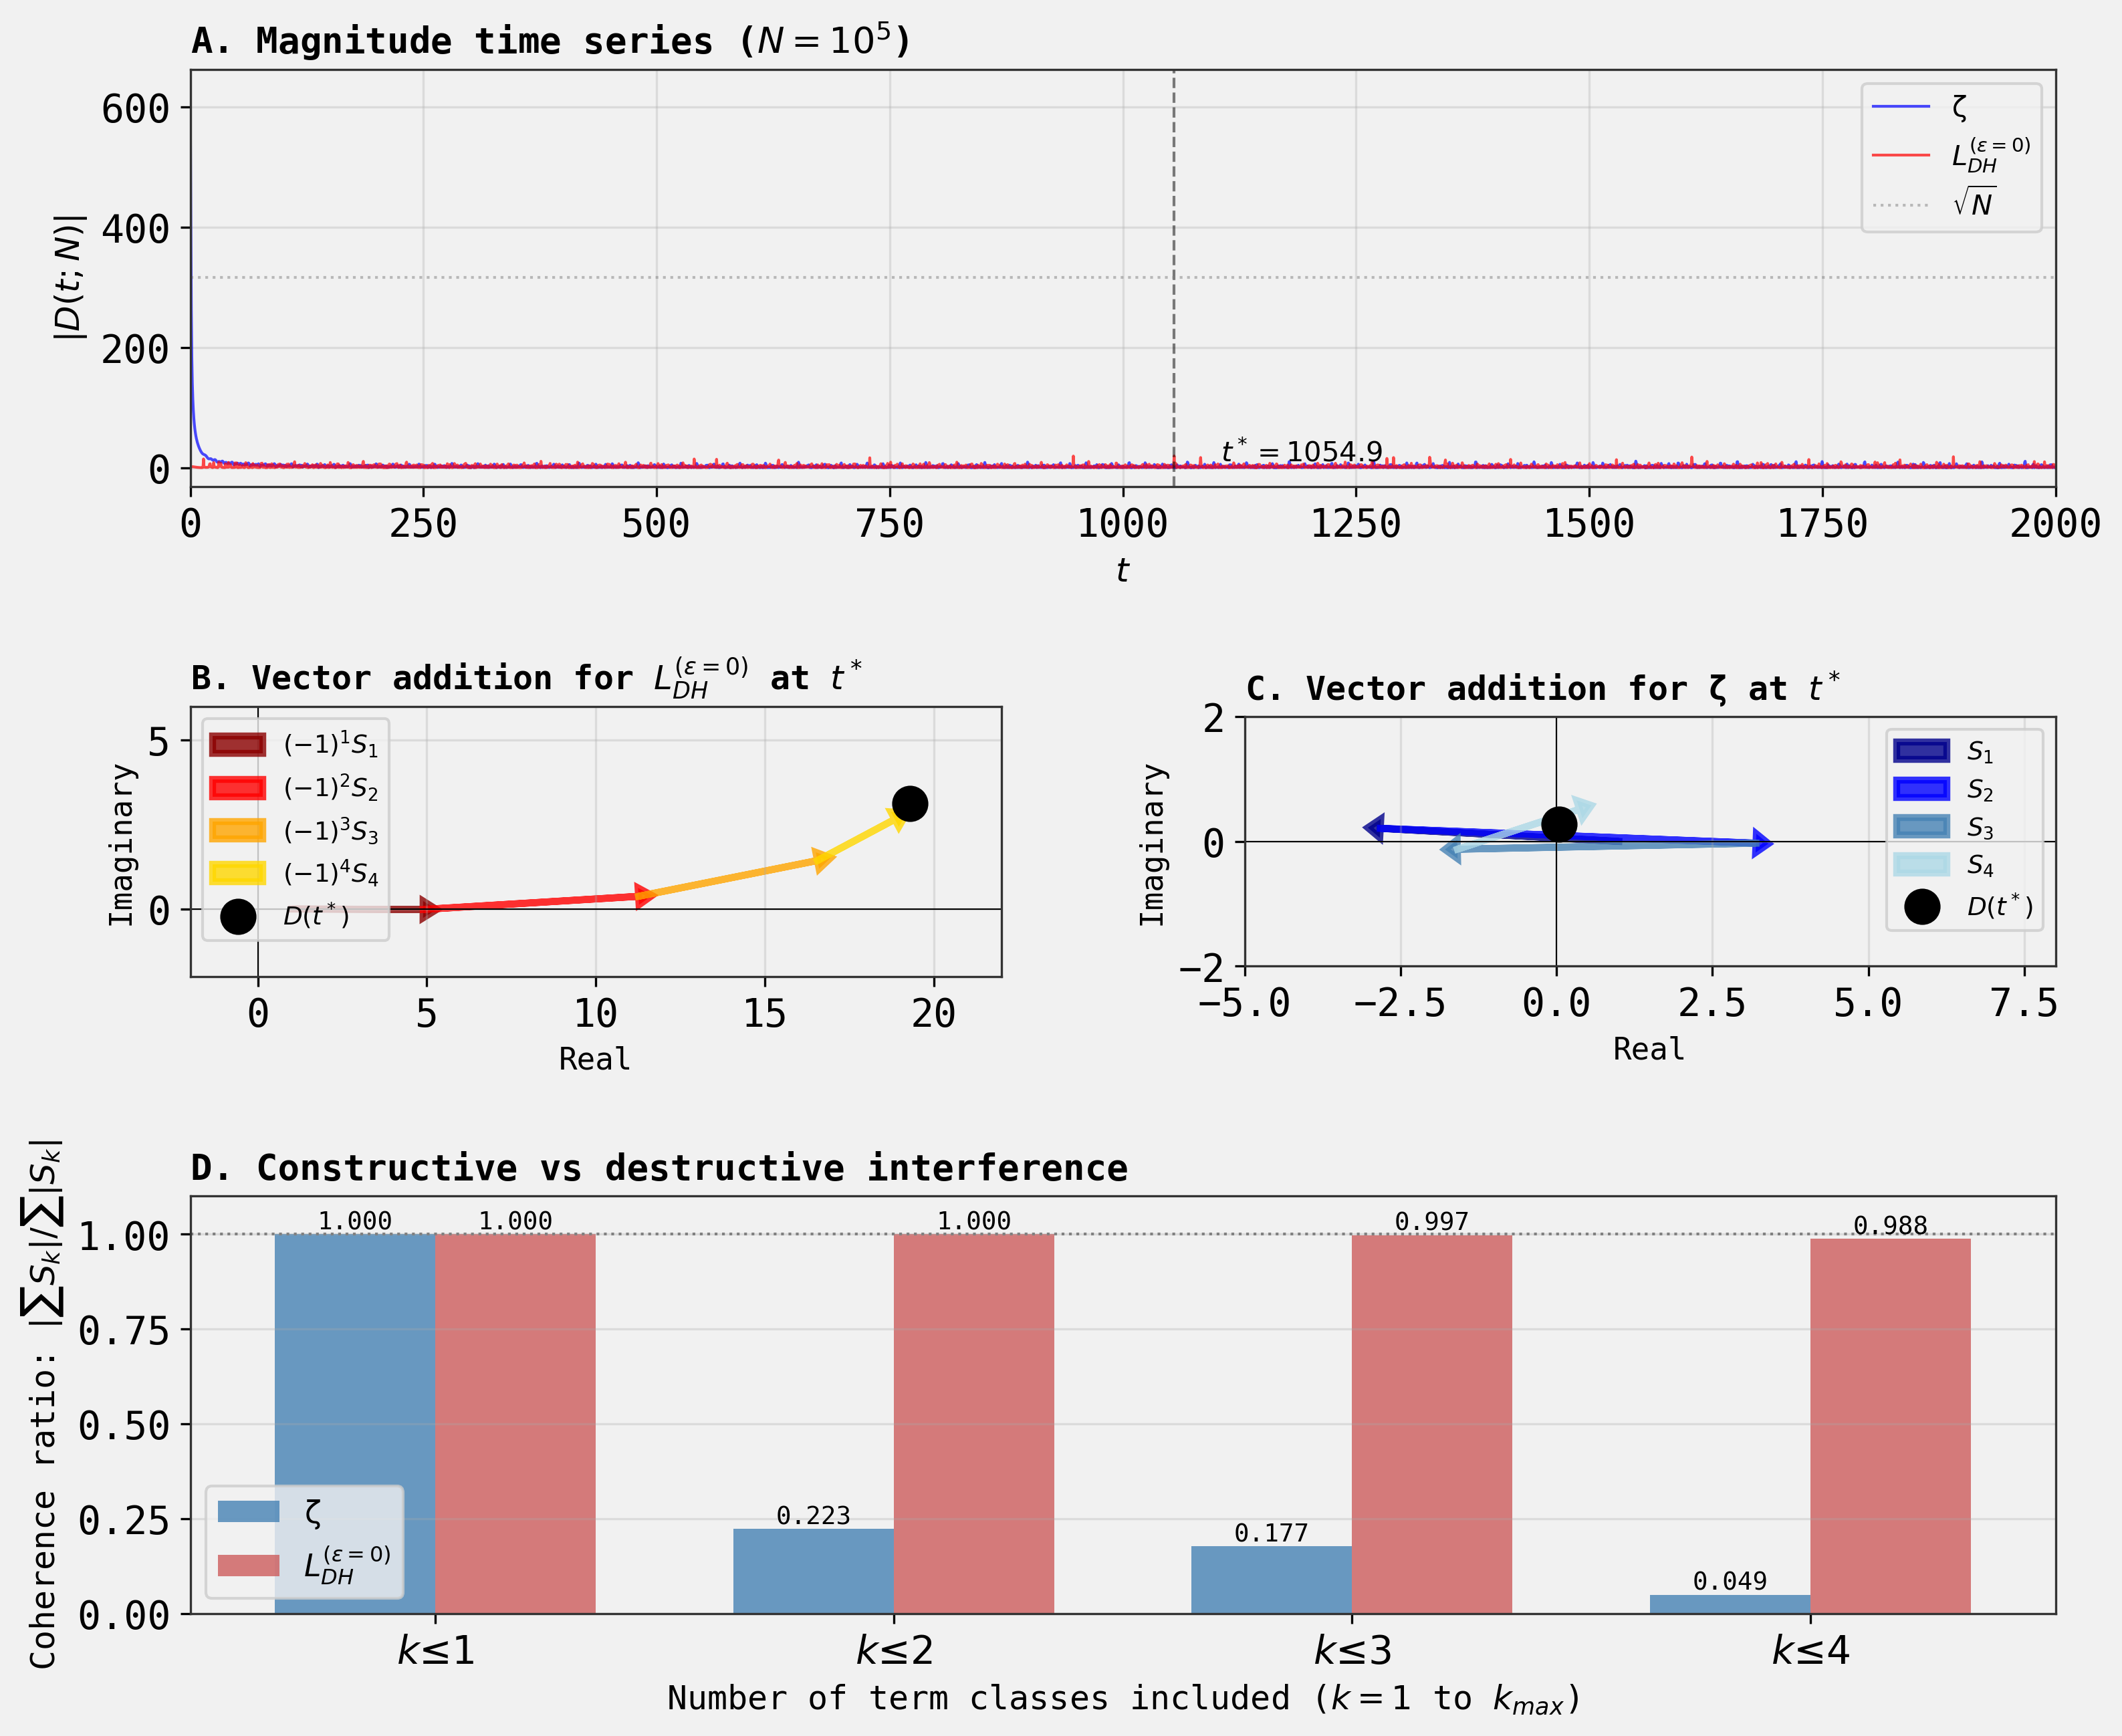

Final figure saved as 'final_analysis_figure.png'


In [32]:

# Now let me create the final summary figure for the analysis
# This should capture the key findings about the mechanism

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Panel A: Time series showing the peaks
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_values, mag_zeta, 'b-', alpha=0.7, linewidth=1, label='ζ')
ax1.plot(t_values, mag_L_DH, 'r-', alpha=0.7, linewidth=1, label='$L_{DH}^{(ε=0)}$')
ax1.axvline(t_star, color='k', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(np.sqrt(N), color='gray', linestyle=':', alpha=0.5, linewidth=1, label='$\\sqrt{N}$')
ax1.set_xlabel('$t$', fontsize=12)
ax1.set_ylabel('$|D(t; N)|$', fontsize=12)
ax1.set_title('A. Magnitude time series ($N = 10^5$)', fontsize=13, loc='left', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 2000])
ax1.text(t_star + 50, 1, f'$t^* = {t_star:.1f}$', fontsize=10, verticalalignment='bottom')

# Panel B: Term-class vector plot (just L_DH for clarity)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

# Cumulative sum visualization
cumsum = 1.0 + 0.0j
colors_gradient = ['darkred', 'red', 'orange', 'gold']
for k in range(1, 5):
 val = (-1)**k * S_k_L_DH_no_coeff[k]
 # Draw from cumsum to cumsum + val
 ax2.arrow(cumsum.real, cumsum.imag, val.real, val.imag, 
 head_width=0.5, head_length=0.4, fc=colors_gradient[k-1], 
 ec=colors_gradient[k-1], linewidth=2.5, alpha=0.8,
 label=f'$(-1)^{k}S_{k}$')
 cumsum += val

# Mark the final sum
ax2.plot(D_L_DH_series[idx_L_DH_peak].real, D_L_DH_series[idx_L_DH_peak].imag, 
 'ko', markersize=12, label='$D(t^*)$', zorder=10)

ax2.set_xlabel('Real', fontsize=11)
ax2.set_ylabel('Imaginary', fontsize=11)
ax2.set_title('B. Vector addition for $L_{DH}^{(ε=0)}$ at $t^*$', fontsize=12, 
 loc='left', fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xlim([-2, 22])
ax2.set_ylim([-2, 6])

# Panel C: Term-class vector plot for zeta
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linewidth=0.5)
ax3.axvline(x=0, color='k', linewidth=0.5)

# Cumulative sum visualization for zeta
cumsum = 1.0 + 0.0j
colors_gradient_zeta = ['darkblue', 'blue', 'steelblue', 'lightblue']
for k in range(1, 5):
 val = S_k_zeta_no_coeff[k]
 ax3.arrow(cumsum.real, cumsum.imag, val.real, val.imag, 
 head_width=0.3, head_length=0.2, fc=colors_gradient_zeta[k-1], 
 ec=colors_gradient_zeta[k-1], linewidth=2.5, alpha=0.8,
 label=f'$S_{k}$')
 cumsum += val

# Mark the final sum
ax3.plot(D_zeta_series[idx_L_DH_peak].real, D_zeta_series[idx_L_DH_peak].imag, 
 'ko', markersize=12, label='$D(t^*)$', zorder=10)

ax3.set_xlabel('Real', fontsize=11)
ax3.set_ylabel('Imaginary', fontsize=11)
ax3.set_title('C. Vector addition for ζ at $t^*$', fontsize=12, 
 loc='left', fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.set_xlim([-5, 8])
ax3.set_ylim([-2, 2])

# Panel D: Coherence comparison
ax4 = fig.add_subplot(gs[2, :])
k_values = np.arange(1, 5)
coherence_ratios_zeta = []
coherence_ratios_L_DH = []

for k_max in k_values:
 sum_zeta = sum([S_k_zeta_no_coeff[k] for k in range(1, k_max + 1)])
 sum_L_DH = sum([(-1)**k * S_k_L_DH_no_coeff[k] for k in range(1, k_max + 1)])
 
 mag_sum_zeta = sum([abs(S_k_zeta_no_coeff[k]) for k in range(1, k_max + 1)])
 mag_sum_L_DH = sum([abs(S_k_L_DH_no_coeff[k]) for k in range(1, k_max + 1)])
 
 coherence_ratios_zeta.append(abs(sum_zeta) / mag_sum_zeta)
 coherence_ratios_L_DH.append(abs(sum_L_DH) / mag_sum_L_DH)

x = np.arange(len(k_values))
width = 0.35

bars1 = ax4.bar(x - width/2, coherence_ratios_zeta, width, label='ζ', 
 color='steelblue', alpha=0.8)
bars2 = ax4.bar(x + width/2, coherence_ratios_L_DH, width, label='$L_{DH}^{(ε=0)}$', 
 color='indianred', alpha=0.8)

ax4.set_xlabel('Number of term classes included ($k = 1$ to $k_{max}$)', fontsize=12)
ax4.set_ylabel('Coherence ratio: $|\\sum S_k| / \\sum |S_k|$', fontsize=12)
ax4.set_title('D. Constructive vs destructive interference', fontsize=13, 
 loc='left', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([f'$k≤{k}$' for k in k_values])
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([0, 1.1])
ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1)

# Add value labels on bars
for bars in [bars1, bars2]:
 for bar in bars:
 height = bar.get_height()
 ax4.text(bar.get_x() + bar.get_width()/2., height,
 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.savefig('final_analysis_figure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Final figure saved as 'final_analysis_figure.png'")


In [33]:

# Perfect! Now let me write the comprehensive conclusion

print("="*80)
print("FINAL CONCLUSIONS")
print("="*80)

print("\n1. HYPOTHESIS PART 1: HIGH |D(t*)| FOR L_DH")
print(" Status: CONFIRMED ✓")
print(f"\n At t* = {t_star:.2f}:")
print(f" - L_DH^(ε=0): |D(t*)| = {abs(D_L_DH_series[idx_L_DH_peak]):.2f}")
print(f" - ζ: |D(t*)| = {abs(D_zeta_series[idx_L_DH_peak]):.2f}")
print(f" - Ratio: {abs(D_L_DH_series[idx_L_DH_peak]) / abs(D_zeta_series[idx_L_DH_peak]):.1f}×")

print("\n Mechanism:")
print(" - The alternating signs (-1)^ω(n) cause term-class vectors to ALIGN")
print(" - For L_DH: Signed vectors (-1)^k S_k point in nearly the same direction")
print(" (angles between consecutive vectors: 4° to 17°)")
print(" - Coherence ratio: 98.8% of potential magnitude is retained")
print(" - For ζ: Vectors S_k alternate in phase (~180° apart)")
print(" (angles between consecutive vectors: ~163° to ~179°)")
print(" - Coherence ratio: Only 4.9% of potential magnitude is retained")

print("\n2. HYPOTHESIS PART 2: R_comp BEHAVIOR")
print(" Status: PARTIALLY CONTRADICTED ✗")

print("\n Expected: L_DH should have LOW R_comp due to phase incoherence")
print(" Found: At resonance peaks:")
print(f" - L_DH peaks: mean R_comp = {np.mean(R_comp_at_L_DH_peaks):.3f}")
print(f" - ζ peaks: mean R_comp = {np.mean(R_comp_at_zeta_peaks):.3f}")

print("\n Revised interpretation:")
print(" - Both functions have uniform phase distributions for composite terms")
print(" - The difference is not in phase incoherence, but in CONSTRUCTIVE vs")
print(" DESTRUCTIVE interference between term classes")
print(" - At L_DH resonances, composite terms (k≥2) contribute ~76% of total")
print(" - At ζ resonances, composite terms contribute ~20% of total")
print(" - The 'low R_comp' mentioned in the dataset description may refer to")
print(" a different definition or normalization than |composite|/|total|")

print("\n3. KEY MECHANISTIC INSIGHT:")
print(" The coefficient structure a_n = (-1)^ω(n) creates TWO effects:")
print(" a) ALIGNMENT: Different ω-classes add constructively when weighted by (-1)^ω")
print(" b) ENHANCEMENT: Composite terms (k≥2) dominate over primes at resonance")
print(" Together, these produce the large |D(t*)| values characteristic of L_DH")

print("\n" + "="*80)


FINAL CONCLUSIONS

1. HYPOTHESIS PART 1: HIGH |D(t*)| FOR L_DH
 Status: CONFIRMED ✓

 At t* = 1054.94:
 - L_DH^(ε=0): |D(t*)| = 19.55
 - ζ: |D(t*)| = 0.28
 - Ratio: 69.9×

 Mechanism:
 - The alternating signs (-1)^ω(n) cause term-class vectors to ALIGN
 - For L_DH: Signed vectors (-1)^k S_k point in nearly the same direction
 (angles between consecutive vectors: 4° to 17°)
 - Coherence ratio: 98.8% of potential magnitude is retained
 - For ζ: Vectors S_k alternate in phase (~180° apart)
 (angles between consecutive vectors: ~163° to ~179°)
 - Coherence ratio: Only 4.9% of potential magnitude is retained

2. HYPOTHESIS PART 2: R_comp BEHAVIOR
 Status: PARTIALLY CONTRADICTED ✗

 Expected: L_DH should have LOW R_comp due to phase incoherence
 Found: At resonance peaks:
 - L_DH peaks: mean R_comp = 0.756
 - ζ peaks: mean R_comp = 0.203

 Revised interpretation:
 - Both functions have uniform phase distributions for composite terms
 - The difference is not in phase incoherence, but in CONST